### plot 2d plot and save npz, get min

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\cav_swap_1d_len_loop_freq_fock1_20260709_1747_to_20260709_1757_I.npz


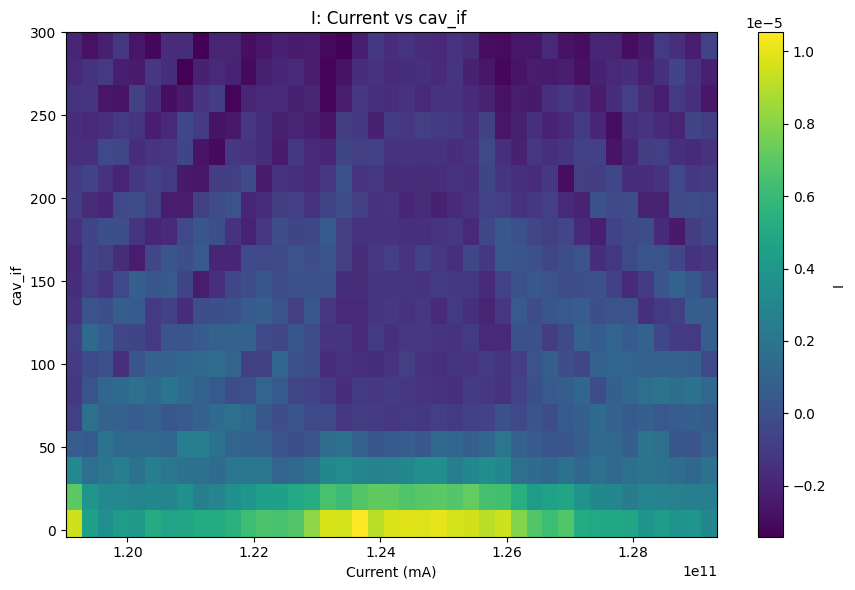

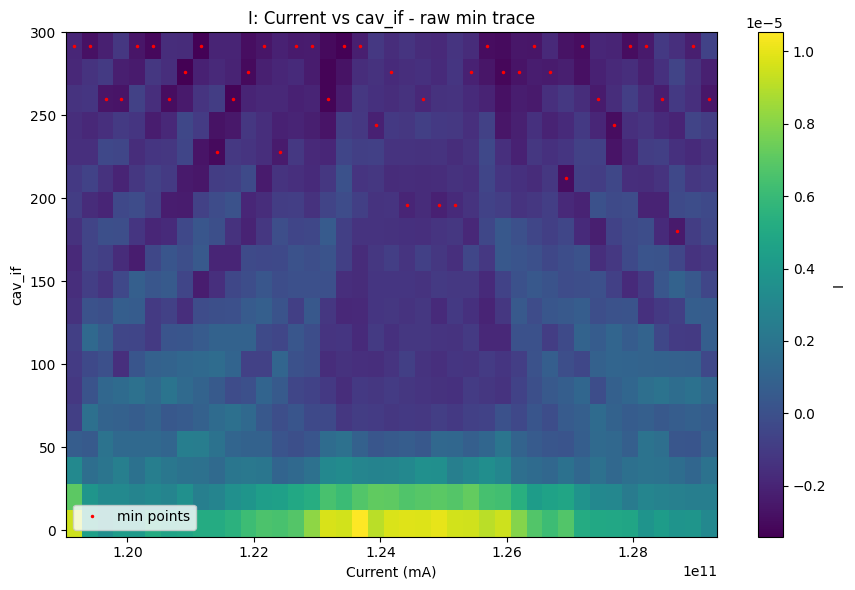

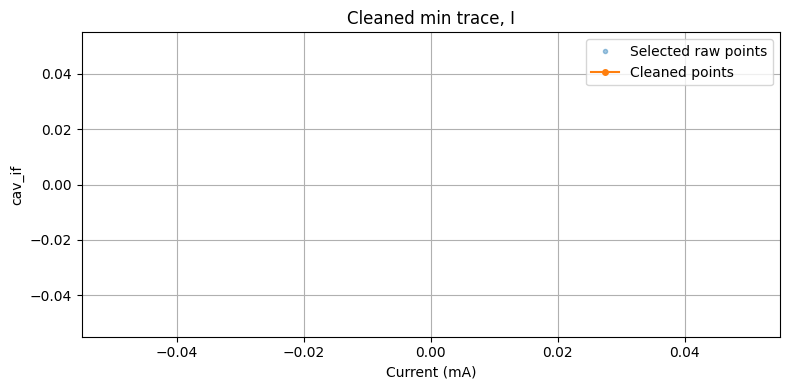

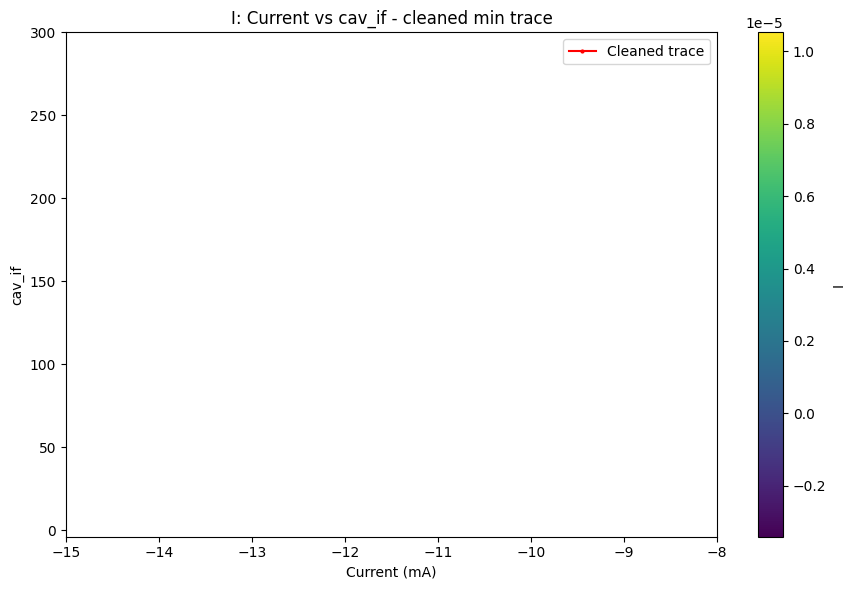


current = []

cav_if = []


In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
current_A_print =np.linspace(start=124.15e6-5e6, stop=124.2e6+5e6, num=41)
batches = [
    {
        "date": "2026-07-09",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-09",
        "time": ((17, 47), (17, 57)),
        "current": current_A_print#[0:104]#np.linspace(-20e-3, 20e-3, 801)[0:237],
    },
    # {
    #     "date": "2026-07-05",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "time": ((0, 0), (6, 0)),
    #     "current": np.linspace(-20e-3, 20e-3, 801)[237:237+274],
    # },
]

file_key = "cav_swap_1d_len_loop_freq_fock1"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

Using the first 438 files and x values.
Batch 0: using 438 files from C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-13
Loading 1/438: 14-17-01_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 2/438: 14-17-21_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 3/438: 14-17-40_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 4/438: 14-18-00_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 5/438: 14-18-20_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 6/438: 14-18-39_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 7/438: 14-18-59_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 8/438: 14-19-19_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 9/438: 14-19-39_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 10/438: 14-19-59_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 11/438: 14-20-19_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 12/438: 14-20-39_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 13/438: 14-20-58_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 14/438: 14-21-18_cav_swap_1d_len_loop_freq_fock1.hdf5
Loading 15/438

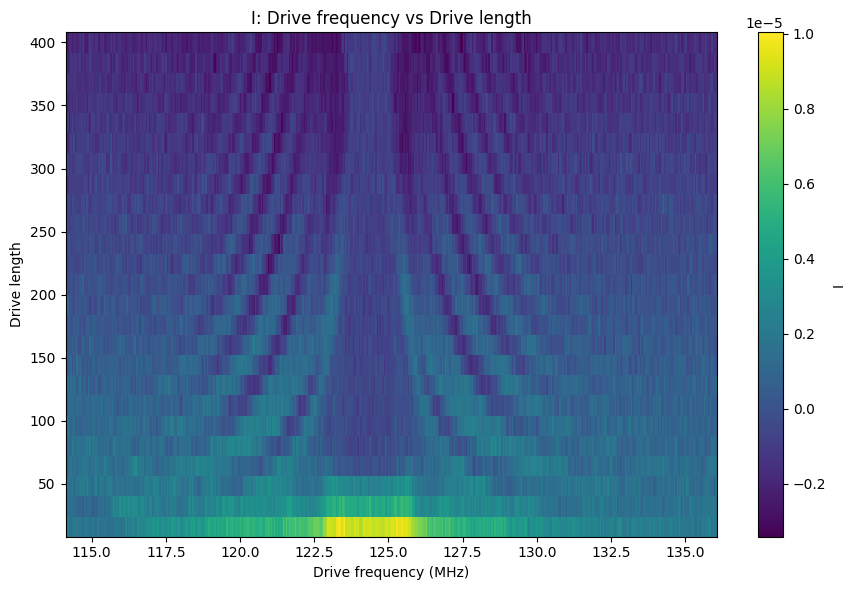

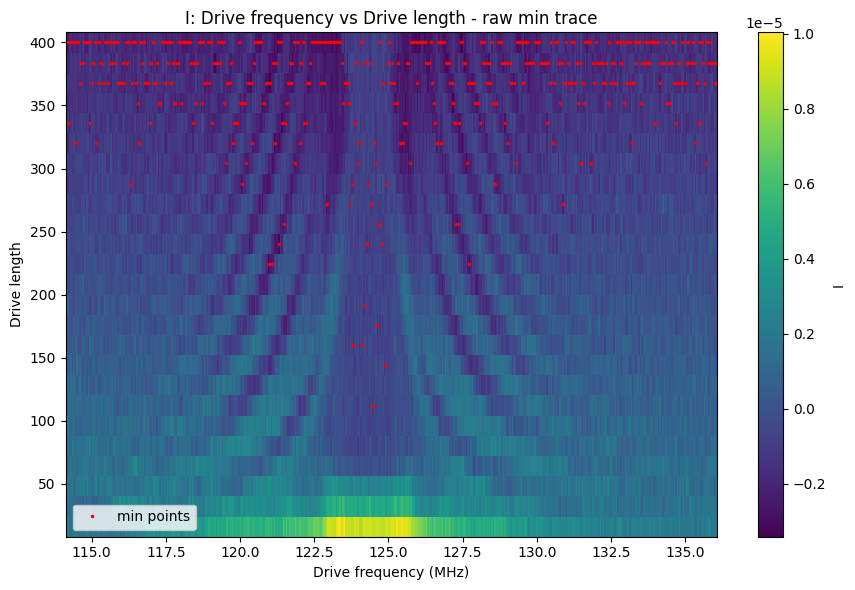

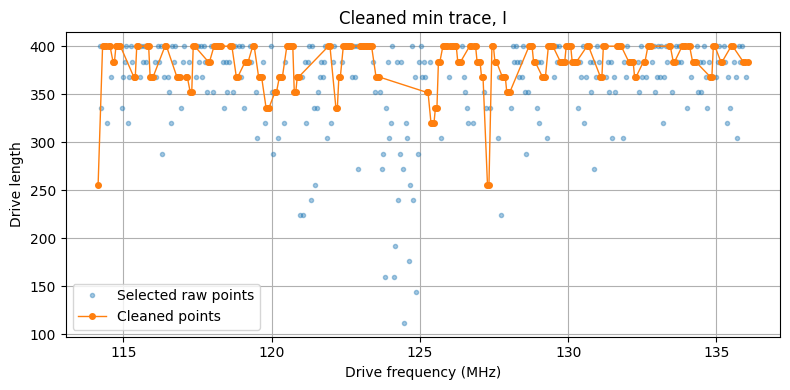

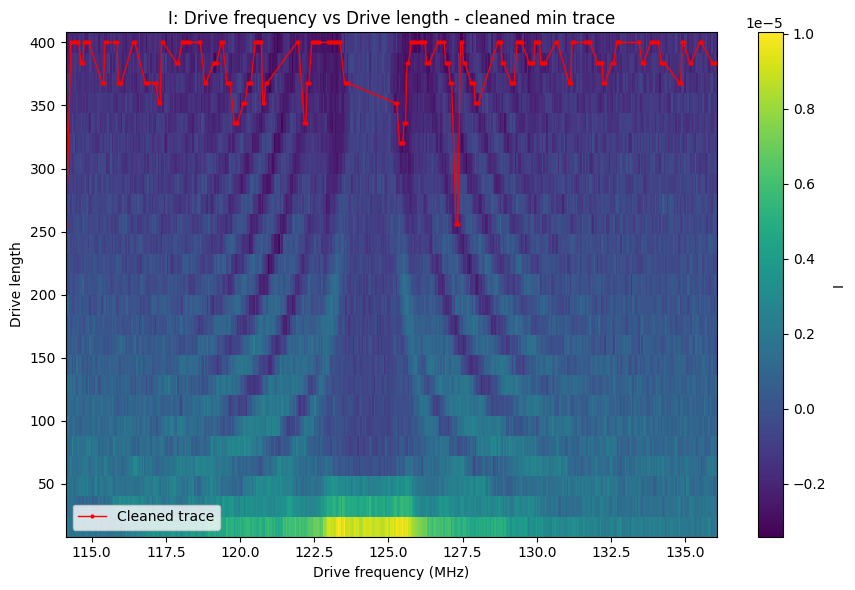


Saved extracted trace to:
C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\cav_swap_1d_len_loop_freq_fock1_20260713_1417_to_20260713_1640_I_min_trace_min_to_maxMHz_cleaned.npz

x = [114150000, 114300341, 114350455, 114400568, 114500795, 114550909, 114651136, 114701250, 114751364, 114801477, 114851591, 114901705, 115352727, 115402841, 115452955, 115503068, 115803750, 115853864, 115903977, 115954091, 116004205, 116405114, 116455227, 116806023, 116856136, 116906250, 117106705, 117156818, 117257045, 117307159, 117357273, 117407386, 117858409, 117908523, 118058864, 118108977, 118159091, 118209205, 118259318, 118309432, 118610114, 118660227, 118810568, 118860682, 119111250, 119161364, 119211477, 119361818, 119411932, 119562273, 119612386, 119662500, 119812841, 119862955, 119913068, 120113523, 120163636, 120263864, 120313977, 120364091, 120514432, 120564545, 120614659, 120664773, 120714886, 120765000, 120815114, 120865227, 120915341, 121917614, 121967727, 122168182, 12221

In [2]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = True
load_npz_for_analysis = True

# ----------------------------------------------------------
# Measurement batches
#
# Each batch requires:
#   folder: directory containing HDF5 files
#   time:   ((start_hour, start_minute), (end_hour, end_minute))
#   x:      x-axis value corresponding to each file
#
# The time may optionally include seconds:
#   ((14, 17, 0), (16, 40, 30))
# ----------------------------------------------------------

drive_frequency_sweep = np.linspace(
    124.15e6 - 10e6,
    124.2e6 + 12e6,
    441,
)

batches = [
    {
        "date": "2026-07-13",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-13",
        "time": ((14, 17), (16, 40)),
        "x": drive_frequency_sweep,
    },

    # {
    #     "date": "2026-07-14",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-14",
    #     "time": ((10, 0), (12, 0)),
    #     "x": np.linspace(130e6, 140e6, 201),
    # },
]


# ----------------------------------------------------------
# HDF5 settings
# ----------------------------------------------------------

file_key = "cav_swap_1d_len_loop_freq_fock1"

# Available options:
#   "I", "Q", "MAG", "PHASE"
plot_data = "I"

# Set explicitly if known, for example:
#   y_key = "drive_len"
#
# None means automatically select a suitable 1D HDF5 dataset.
y_key = None

# Preferred names when automatically finding the sweep axis.
preferred_y_keys = [
    "drive_len",
    "drive_length",
    "sweep",
    "sweep_axis",
    "frequency",
    "freq",
    "time",
    "delay",
    "duration",
    "current",
    "flux",
    "power",
    "amplitude",
]

# Signal dataset names inside the HDF5 files.
i_dataset = "I"
q_dataset = "Q"
magnitude_dataset = "Magnitude"

# If the signal has multiple dimensions, all dimensions other
# than the sweep-axis dimension are averaged.
subtract_mean = True


# ----------------------------------------------------------
# Axis display settings
#
# displayed_value = raw_value * display_scale
#
# Examples:
#   Hz  -> MHz: 1e-6
#   Hz  -> GHz: 1e-9
#   s   -> ns:  1e9
#   A   -> mA:  1e3
# ----------------------------------------------------------

x_label = "Drive frequency"
x_unit = "MHz"
x_display_scale = 1e-6

y_label = "Drive length"
y_unit = ""
y_display_scale = 1.0


# ----------------------------------------------------------
# File-count mismatch behavior
#
# "truncate":
#     Use the smaller of the number of files and x values.
#
# "raise":
#     Stop if the number of files and x values are different.
# ----------------------------------------------------------

file_count_mismatch = "truncate"


# ----------------------------------------------------------
# Plot settings
# ----------------------------------------------------------

colormap = "viridis"
show_individual_plots = False


# ----------------------------------------------------------
# Trace extraction settings
# ----------------------------------------------------------

find_mode = "min"       # "min" or "max"

# Range is specified in displayed x-axis units.
# For example, with x_unit="MHz":
#   trace_x_range = (120, 130)
#
# Use None for no lower or upper restriction.
trace_x_range = (None, None)

remove_outliers = True

# Threshold is specified in displayed y-axis units.
#
# For example:
#   if y is displayed in MHz, 5.0 means 5 MHz.
#   if y is displayed in ns, 10.0 means 10 ns.
jump_threshold_display = 5.0

save_extracted_trace = True


# ----------------------------------------------------------
# Output settings
# ----------------------------------------------------------

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria"
    r"\scripts\plot\data_plot_data"
)

os.makedirs(output_folder, exist_ok=True)

# Set to None to generate the filename automatically.
npz_filename = None


# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def format_axis_label(label, unit):
    """Return an axis label with an optional unit."""
    if unit:
        return f"{label} ({unit})"
    return label


def time_to_seconds(time_tuple):
    """
    Convert (hour, minute) or (hour, minute, second) into seconds
    from the start of the day.
    """
    if len(time_tuple) == 2:
        hour, minute = time_tuple
        second = 0
    elif len(time_tuple) == 3:
        hour, minute, second = time_tuple
    else:
        raise ValueError(
            f"Invalid time {time_tuple}. "
            "Use (hour, minute) or (hour, minute, second)."
        )

    return 3600 * int(hour) + 60 * int(minute) + int(second)


def extract_time(filename):
    """
    Extract HH-MM-SS or HH-MM from a filename.

    Examples:
        14-17-25_measurement.hdf5
        14-17_measurement.hdf5

    Returns
    -------
    int
        Seconds from the beginning of the day.
        Returns -1 when no time can be identified.
    """
    basename = os.path.basename(filename)

    match = re.search(
        r"(?<!\d)(\d{1,2})-(\d{2})(?:-(\d{2}))?(?!\d)",
        basename,
    )

    if match is None:
        return -1

    hour = int(match.group(1))
    minute = int(match.group(2))
    second = int(match.group(3) or 0)

    if not (0 <= hour <= 23):
        return -1

    if not (0 <= minute <= 59):
        return -1

    if not (0 <= second <= 59):
        return -1

    return 3600 * hour + 60 * minute + second


def seconds_to_time_string(seconds):
    """Convert seconds from the start of the day to HH:MM:SS."""
    if seconds < 0:
        return "unknown"

    hour = seconds // 3600
    minute = (seconds % 3600) // 60
    second = seconds % 60

    return f"{hour:02d}:{minute:02d}:{second:02d}"


def get_filtered_files(
    folder,
    start_time,
    end_time,
    filename_key,
):
    """Find matching HDF5 files inside the requested time interval."""
    if not os.path.isdir(folder):
        print(f"Folder not found: {folder}")
        return []

    start_seconds = time_to_seconds(start_time)
    end_seconds = time_to_seconds(end_time)

    matched_files = []

    for filename in os.listdir(folder):
        if not filename.lower().endswith((".hdf5", ".h5")):
            continue

        if filename_key and filename_key not in filename:
            continue

        full_path = os.path.join(folder, filename)
        file_time = extract_time(filename)

        if start_seconds <= file_time <= end_seconds:
            matched_files.append(full_path)

    matched_files.sort(
        key=lambda path: (
            extract_time(path),
            os.path.basename(path),
        )
    )

    return matched_files


def get_batch_x_values(batch):
    """
    Obtain x values from a batch.

    The generic key is 'x'. The older key 'current' is also
    supported for backward compatibility.
    """
    if "x" in batch:
        return np.asarray(batch["x"], dtype=float)

    if "current" in batch:
        return np.asarray(batch["current"], dtype=float)

    raise KeyError(
        "Each batch must contain an 'x' array. "
        "For backward compatibility, 'current' is also accepted."
    )


def list_numeric_datasets(hdf5_file):
    """Return basic information about numeric HDF5 datasets."""
    information = []

    def visitor(name, obj):
        if not isinstance(obj, h5py.Dataset):
            return

        try:
            array = np.asarray(obj[()])
        except Exception:
            return

        if not np.issubdtype(array.dtype, np.number):
            return

        information.append(
            {
                "name": name,
                "shape": array.shape,
                "ndim": array.ndim,
                "size": array.size,
            }
        )

    hdf5_file.visititems(visitor)

    return information


def automatically_choose_y_key(hdf5_file):
    """
    Automatically choose a numeric 1D dataset as the sweep axis.
    """
    excluded_keys = {
        i_dataset,
        q_dataset,
        magnitude_dataset,
    }

    dataset_info = list_numeric_datasets(hdf5_file)

    signal_shapes = []

    for signal_name in excluded_keys:
        if signal_name in hdf5_file:
            signal_shapes.append(
                np.asarray(hdf5_file[signal_name][()]).shape
            )

    candidates = []

    for info in dataset_info:
        name = info["name"]
        short_name = name.split("/")[-1]

        if name in excluded_keys or short_name in excluded_keys:
            continue

        if info["ndim"] != 1:
            continue

        score = 0
        lower_name = short_name.lower()

        # Strong preference for explicitly listed axis names.
        for priority, preferred_name in enumerate(preferred_y_keys):
            if lower_name == preferred_name.lower():
                score += 1000 - priority
                break

        # Partial-name matching.
        axis_words = [
            "sweep",
            "freq",
            "time",
            "delay",
            "length",
            "len",
            "duration",
            "current",
            "flux",
            "power",
            "amp",
        ]

        if any(word in lower_name for word in axis_words):
            score += 100

        # Prefer a length that matches one signal dimension.
        for shape in signal_shapes:
            if info["size"] in shape:
                score += 50

        candidates.append((score, name, info["size"]))

    if not candidates:
        available = [
            f"{d['name']}: shape={d['shape']}"
            for d in dataset_info
        ]

        raise KeyError(
            "Could not automatically find a 1D sweep-axis dataset.\n"
            "Set y_key explicitly.\n"
            "Available numeric datasets:\n  "
            + "\n  ".join(available)
        )

    candidates.sort(
        key=lambda item: (-item[0], item[1])
    )

    selected_key = candidates[0][1]

    if len(candidates) > 1:
        candidate_text = ", ".join(
            f"{name} (score={score}, length={length})"
            for score, name, length in candidates
        )

        print(
            f"Automatically selected y_key='{selected_key}'.\n"
            f"Candidates: {candidate_text}"
        )

    return selected_key


def reduce_to_1d_trace(array, expected_length, dataset_name):
    """
    Reduce an arbitrary-dimensional signal to one dimension.

    The axis whose length equals expected_length is treated as the
    sweep axis. All other axes are averaged.
    """
    array = np.asarray(array)
    array = np.squeeze(array)

    if array.ndim == 0:
        raise ValueError(
            f"Dataset '{dataset_name}' is scalar and cannot form a trace."
        )

    if array.ndim == 1:
        if len(array) != expected_length:
            raise ValueError(
                f"Dataset '{dataset_name}' has length {len(array)}, "
                f"but the sweep axis has length {expected_length}."
            )

        return array.astype(float)

    matching_axes = [
        axis
        for axis, axis_length in enumerate(array.shape)
        if axis_length == expected_length
    ]

    if not matching_axes:
        raise ValueError(
            f"Cannot identify the sweep dimension of '{dataset_name}'.\n"
            f"Signal shape: {array.shape}\n"
            f"Sweep-axis length: {expected_length}"
        )

    # Prefer the final matching dimension, which is the common
    # convention for repeated traces.
    sweep_dimension = matching_axes[-1]

    array = np.moveaxis(
        array,
        sweep_dimension,
        -1,
    )

    averaging_axes = tuple(range(array.ndim - 1))

    if averaging_axes:
        array = np.nanmean(
            array,
            axis=averaging_axes,
        )

    return np.asarray(array, dtype=float)


def load_one_hdf5(
    filename,
    requested_y_key=None,
    remove_trace_mean=True,
):
    """
    Load the sweep axis and all available signal representations.

    Returns
    -------
    selected_y_key : str
    y_values : ndarray
    signals : dict
        Possible keys are I, Q, MAG, and PHASE.
    """
    with h5py.File(filename, "r") as hdf5_file:
        selected_y_key = (
            requested_y_key
            if requested_y_key is not None
            else automatically_choose_y_key(hdf5_file)
        )

        if selected_y_key not in hdf5_file:
            raise KeyError(
                f"Dataset '{selected_y_key}' was not found in:\n"
                f"{filename}"
            )

        y_values = np.asarray(
            hdf5_file[selected_y_key][()]
        ).squeeze()

        if y_values.ndim != 1:
            raise ValueError(
                f"Sweep dataset '{selected_y_key}' must be 1D, "
                f"but its shape is {y_values.shape}."
            )

        y_values = y_values.astype(float)
        expected_length = len(y_values)

        signals = {}

        if i_dataset in hdf5_file:
            signals["I"] = reduce_to_1d_trace(
                hdf5_file[i_dataset][()],
                expected_length,
                i_dataset,
            )

        if q_dataset in hdf5_file:
            signals["Q"] = reduce_to_1d_trace(
                hdf5_file[q_dataset][()],
                expected_length,
                q_dataset,
            )

        if magnitude_dataset in hdf5_file:
            signals["MAG"] = reduce_to_1d_trace(
                hdf5_file[magnitude_dataset][()],
                expected_length,
                magnitude_dataset,
            )

        elif "I" in signals and "Q" in signals:
            signals["MAG"] = np.sqrt(
                signals["I"] ** 2 + signals["Q"] ** 2
            )

        if "I" in signals and "Q" in signals:
            signals["PHASE"] = np.unwrap(
                np.arctan2(
                    signals["Q"],
                    signals["I"],
                )
            )

        if remove_trace_mean:
            for signal_name in signals:
                signals[signal_name] = (
                    signals[signal_name]
                    - np.nanmean(signals[signal_name])
                )

    return selected_y_key, y_values, signals


def validate_common_y_axes(all_y_values):
    """
    Confirm that every file uses the same sweep axis.

    A rectangular 2D map cannot be constructed if the sweep axes
    have different values or different lengths.
    """
    reference = np.asarray(all_y_values[0])

    for index, axis in enumerate(all_y_values[1:], start=1):
        axis = np.asarray(axis)

        if axis.shape != reference.shape:
            raise ValueError(
                f"File index {index} has y shape {axis.shape}, "
                f"while the first file has shape {reference.shape}."
            )

        if not np.allclose(
            axis,
            reference,
            rtol=1e-9,
            atol=1e-12,
            equal_nan=True,
        ):
            maximum_difference = np.nanmax(
                np.abs(axis - reference)
            )

            raise ValueError(
                "The sweep-axis values are not identical between files.\n"
                f"File index: {index}\n"
                f"Maximum difference: {maximum_difference}"
            )

    return reference


def make_default_npz_name():
    """Generate an output filename from the batch information."""
    first_batch = batches[0]
    last_batch = batches[-1]

    first_date = first_batch.get(
        "date",
        "unknown",
    ).replace("-", "")

    last_date = last_batch.get(
        "date",
        "unknown",
    ).replace("-", "")

    start_time = time_to_seconds(
        first_batch["time"][0]
    )

    end_time = time_to_seconds(
        last_batch["time"][1]
    )

    start_hour = start_time // 3600
    start_minute = (start_time % 3600) // 60

    end_hour = end_time // 3600
    end_minute = (end_time % 3600) // 60

    safe_file_key = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        file_key,
    )

    return (
        f"{safe_file_key}_"
        f"{first_date}_{start_hour:02d}{start_minute:02d}_to_"
        f"{last_date}_{end_hour:02d}{end_minute:02d}_"
        f"{plot_data.upper()}.npz"
    )


def plot_2d_map(
    x_values,
    y_values,
    z_values,
    title_suffix="",
):
    """Plot a generic x-versus-y 2D measurement map."""
    x_display = np.asarray(x_values) * x_display_scale
    y_display = np.asarray(y_values) * y_display_scale

    z_values = np.asarray(z_values)

    if z_values.shape != (
        len(x_values),
        len(y_values),
    ):
        raise ValueError(
            "The 2D signal has an unexpected shape.\n"
            f"Expected: {(len(x_values), len(y_values))}\n"
            f"Received: {z_values.shape}"
        )

    plt.figure(figsize=(9, 6))

    plt.pcolormesh(
        x_display,
        y_display,
        z_values.T,
        shading="auto",
        cmap=colormap,
    )

    plt.xlabel(
        format_axis_label(
            x_label,
            x_unit,
        )
    )

    plt.ylabel(
        format_axis_label(
            y_label,
            y_unit,
        )
    )

    title = f"{plot_data}: {x_label} vs {y_label}"

    if title_suffix:
        title += f" {title_suffix}"

    plt.title(title)
    plt.colorbar(label=plot_data)
    plt.tight_layout()


def find_row_extrema(data_2d, mode):
    """
    Find the minimum or maximum point along y for each x.

    Rows containing no finite values return an index of -1.
    """
    data_2d = np.asarray(data_2d)
    valid_rows = np.any(
        np.isfinite(data_2d),
        axis=1,
    )

    indices = np.full(
        data_2d.shape[0],
        -1,
        dtype=int,
    )

    if mode == "min":
        indices[valid_rows] = np.nanargmin(
            data_2d[valid_rows],
            axis=1,
        )

    elif mode == "max":
        indices[valid_rows] = np.nanargmax(
            data_2d[valid_rows],
            axis=1,
        )

    else:
        raise ValueError(
            "find_mode must be either 'min' or 'max'."
        )

    values = np.full(
        data_2d.shape[0],
        np.nan,
        dtype=float,
    )

    row_numbers = np.arange(
        data_2d.shape[0]
    )

    values[valid_rows] = data_2d[
        row_numbers[valid_rows],
        indices[valid_rows],
    ]

    return indices, values, valid_rows


def make_range_mask(displayed_x, selected_range):
    """Create a mask using optional lower and upper limits."""
    lower_limit, upper_limit = selected_range

    mask = np.isfinite(displayed_x)

    if lower_limit is not None:
        mask &= displayed_x >= lower_limit

    if upper_limit is not None:
        mask &= displayed_x <= upper_limit

    return mask


def remove_isolated_jumps(y_display, threshold):
    """
    Remove an isolated point when it differs strongly from both
    immediate neighbours.

    This does not remove a genuine step that continues into the
    following points.
    """
    good_mask = np.isfinite(y_display)

    if len(y_display) < 3:
        return good_mask

    jump_from_left = np.abs(
        y_display[1:-1] - y_display[:-2]
    )

    jump_from_right = np.abs(
        y_display[1:-1] - y_display[2:]
    )

    isolated_jump = (
        (jump_from_left > threshold)
        & (jump_from_right > threshold)
    )

    good_mask[1:-1] &= ~isolated_jump

    return good_mask


# ==========================================================
# OUTPUT PATH
# ==========================================================

plot_data = plot_data.upper()

if plot_data not in {"I", "Q", "MAG", "PHASE"}:
    raise ValueError(
        "plot_data must be 'I', 'Q', 'MAG', or 'PHASE'."
    )

if npz_filename is None:
    npz_filename = make_default_npz_name()

npz_path = os.path.join(
    output_folder,
    npz_filename,
)


# ==========================================================
# BUILD NPZ FROM HDF5
# ==========================================================

if build_npz_from_hdf5:
    grouped_files = []
    all_x_values = []
    file_dates = []
    file_times_seconds = []
    file_batch_indices = []

    for batch_index, batch in enumerate(batches):
        files = get_filtered_files(
            folder=batch["folder"],
            start_time=batch["time"][0],
            end_time=batch["time"][1],
            filename_key=file_key,
        )

        batch_x_values = get_batch_x_values(batch)

        if len(files) != len(batch_x_values):
            message = (
                f"Batch {batch_index}: found {len(files)} files "
                f"but received {len(batch_x_values)} x values."
            )

            if file_count_mismatch == "raise":
                raise ValueError(message)

            if file_count_mismatch != "truncate":
                raise ValueError(
                    "file_count_mismatch must be 'truncate' or 'raise'."
                )

            number_to_use = min(
                len(files),
                len(batch_x_values),
            )

            print(
                f"Warning: {message}\n"
                f"Using the first {number_to_use} files and x values."
            )

        else:
            number_to_use = len(files)

        selected_files = files[:number_to_use]
        selected_x = batch_x_values[:number_to_use]

        grouped_files.extend(selected_files)
        all_x_values.extend(selected_x)

        file_dates.extend(
            [batch.get("date", "")] * number_to_use
        )

        file_times_seconds.extend(
            [extract_time(file) for file in selected_files]
        )

        file_batch_indices.extend(
            [batch_index] * number_to_use
        )

        print(
            f"Batch {batch_index}: using {number_to_use} files "
            f"from {batch['folder']}"
        )

    if not grouped_files:
        raise ValueError(
            "No matching HDF5 files were found."
        )

    all_x_values = np.asarray(
        all_x_values,
        dtype=float,
    )

    all_y_values = []
    signal_lists = {
        "I": [],
        "Q": [],
        "MAG": [],
        "PHASE": [],
    }

    selected_axis_key = None

    for file_index, filename in enumerate(grouped_files):
        print(
            f"Loading {file_index + 1}/{len(grouped_files)}: "
            f"{os.path.basename(filename)}"
        )

        axis_key, file_y_values, signals = load_one_hdf5(
            filename=filename,
            requested_y_key=y_key,
            remove_trace_mean=subtract_mean,
        )

        if selected_axis_key is None:
            selected_axis_key = axis_key

        elif axis_key != selected_axis_key:
            raise ValueError(
                "Different sweep-axis keys were selected between files.\n"
                f"First key: {selected_axis_key}\n"
                f"Current key: {axis_key}\n"
                f"File: {filename}"
            )

        all_y_values.append(file_y_values)

        for signal_name in signal_lists:
            if signal_name in signals:
                signal_lists[signal_name].append(
                    signals[signal_name]
                )

    y_values = validate_common_y_axes(
        all_y_values
    )

    number_of_files = len(grouped_files)

    save_payload = {
        "x_values": all_x_values,
        "y_values": y_values,
        "all_y_values": np.stack(all_y_values),
        "x_label": x_label,
        "x_unit": x_unit,
        "x_display_scale": x_display_scale,
        "y_label": y_label,
        "y_unit": y_unit,
        "y_display_scale": y_display_scale,
        "y_key": selected_axis_key,
        "filenames": np.asarray(
            grouped_files,
            dtype=object,
        ),
        "file_dates": np.asarray(
            file_dates,
            dtype=object,
        ),
        "file_times_seconds": np.asarray(
            file_times_seconds,
            dtype=int,
        ),
        "file_batch_indices": np.asarray(
            file_batch_indices,
            dtype=int,
        ),
        "batch_dates": np.asarray(
            [batch.get("date", "") for batch in batches],
            dtype=object,
        ),
        "batch_start_times": np.asarray(
            [batch["time"][0] for batch in batches],
            dtype=object,
        ),
        "batch_end_times": np.asarray(
            [batch["time"][1] for batch in batches],
            dtype=object,
        ),
        "batch_folders": np.asarray(
            [batch["folder"] for batch in batches],
            dtype=object,
        ),
        "file_key": file_key,
        "subtract_mean": subtract_mean,
        "plot_data_saved": plot_data,
    }

    for signal_name, traces in signal_lists.items():
        if len(traces) == number_of_files:
            save_payload[signal_name] = np.stack(
                traces,
                axis=0,
            )

        elif traces:
            print(
                f"Warning: signal '{signal_name}' was present in "
                f"{len(traces)}/{number_of_files} files and will "
                "not be saved."
            )

    if plot_data not in save_payload:
        raise KeyError(
            f"Requested signal '{plot_data}' was not available "
            "for every HDF5 file."
        )

    np.savez_compressed(
        npz_path,
        **save_payload,
    )

    print(f"\nSaved main NPZ to:\n{npz_path}")


# ==========================================================
# LOAD NPZ AND ANALYZE
# ==========================================================

if load_npz_for_analysis:
    if not os.path.isfile(npz_path):
        raise FileNotFoundError(
            f"NPZ file not found:\n{npz_path}"
        )

    data = np.load(
        npz_path,
        allow_pickle=True,
    )

    if plot_data not in data.files:
        available_signals = [
            key
            for key in ("I", "Q", "MAG", "PHASE")
            if key in data.files
        ]

        raise KeyError(
            f"Signal '{plot_data}' is not stored in the NPZ.\n"
            f"Available signals: {available_signals}"
        )

    x_values = np.asarray(
        data["x_values"],
        dtype=float,
    )

    y_values = np.asarray(
        data["y_values"],
        dtype=float,
    )

    data_2d = np.asarray(
        data[plot_data],
        dtype=float,
    )

    if data_2d.shape != (
        len(x_values),
        len(y_values),
    ):
        raise ValueError(
            f"Signal shape {data_2d.shape} does not match "
            f"x/y dimensions {(len(x_values), len(y_values))}."
        )

    x_display = x_values * x_display_scale
    y_display = y_values * y_display_scale

    # ------------------------------------------------------
    # Raw 2D map
    # ------------------------------------------------------

    plot_2d_map(
        x_values,
        y_values,
        data_2d,
    )

    plt.show()

    # ------------------------------------------------------
    # Optional individual traces
    # ------------------------------------------------------

    if show_individual_plots:
        plt.figure(figsize=(9, 6))

        for row_index, x_value in enumerate(x_display):
            plt.plot(
                y_display,
                data_2d[row_index],
                linewidth=1,
                label=(
                    f"{x_label}={x_value:.6g}"
                    + (f" {x_unit}" if x_unit else "")
                ),
            )

        plt.xlabel(
            format_axis_label(
                y_label,
                y_unit,
            )
        )

        plt.ylabel(plot_data)
        plt.title(f"Individual {plot_data} traces")

        if len(x_values) <= 20:
            plt.legend(fontsize=8)

        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------
    # Extract minimum or maximum point from every row
    # ------------------------------------------------------

    trace_indices, trace_values, valid_rows = find_row_extrema(
        data_2d,
        find_mode,
    )

    trace_y = np.full(
        len(x_values),
        np.nan,
        dtype=float,
    )

    trace_y[valid_rows] = y_values[
        trace_indices[valid_rows]
    ]

    trace_y_display = trace_y * y_display_scale

    # ------------------------------------------------------
    # Plot raw extracted trace over the 2D map
    # ------------------------------------------------------

    plot_2d_map(
        x_values,
        y_values,
        data_2d,
        title_suffix=f"- raw {find_mode} trace",
    )

    plt.plot(
        x_display[valid_rows],
        trace_y_display[valid_rows],
        "r.",
        markersize=3,
        label=f"{find_mode} points",
    )

    plt.legend()
    plt.show()

    # ------------------------------------------------------
    # Select x range
    # ------------------------------------------------------

    range_mask = make_range_mask(
        x_display,
        trace_x_range,
    )

    selection_mask = (
        range_mask
        & valid_rows
        & np.isfinite(trace_y)
        & np.isfinite(trace_values)
    )

    x_selected = x_values[selection_mask]
    x_selected_display = x_display[selection_mask]

    y_selected = trace_y[selection_mask]
    y_selected_display = trace_y_display[selection_mask]

    values_selected = trace_values[selection_mask]

    if len(x_selected) == 0:
        raise ValueError(
            "No trace points remain after applying trace_x_range."
        )

    # ------------------------------------------------------
    # Remove isolated outliers
    # ------------------------------------------------------

    if remove_outliers:
        good_mask = remove_isolated_jumps(
            y_selected_display,
            jump_threshold_display,
        )
    else:
        good_mask = np.ones(
            len(y_selected),
            dtype=bool,
        )

    x_clean = x_selected[good_mask]
    x_clean_display = x_selected_display[good_mask]

    y_clean = y_selected[good_mask]
    y_clean_display = y_selected_display[good_mask]

    value_clean = values_selected[good_mask]

    # ------------------------------------------------------
    # Plot extracted trace before and after cleaning
    # ------------------------------------------------------

    plt.figure(figsize=(8, 4))

    plt.plot(
        x_selected_display,
        y_selected_display,
        "o",
        markersize=3,
        alpha=0.4,
        label="Selected raw points",
    )

    plt.plot(
        x_clean_display,
        y_clean_display,
        "o-",
        markersize=4,
        linewidth=1,
        label="Cleaned points",
    )

    plt.xlabel(
        format_axis_label(
            x_label,
            x_unit,
        )
    )

    plt.ylabel(
        format_axis_label(
            y_label,
            y_unit,
        )
    )

    plt.title(
        f"Cleaned {find_mode} trace, {plot_data}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Cleaned trace over the 2D map
    # ------------------------------------------------------

    plot_2d_map(
        x_values,
        y_values,
        data_2d,
        title_suffix=f"- cleaned {find_mode} trace",
    )

    plt.plot(
        x_clean_display,
        y_clean_display,
        "r.-",
        markersize=4,
        linewidth=1,
        label="Cleaned trace",
    )

    lower_limit, upper_limit = trace_x_range

    if lower_limit is not None or upper_limit is not None:
        current_xlim = plt.xlim()

        plt.xlim(
            lower_limit
            if lower_limit is not None
            else current_xlim[0],
            upper_limit
            if upper_limit is not None
            else current_xlim[1],
        )

    plt.legend()
    plt.show()

    # ------------------------------------------------------
    # Save extracted trace
    # ------------------------------------------------------

    if save_extracted_trace:
        lower_text = (
            "min"
            if trace_x_range[0] is None
            else f"{trace_x_range[0]:g}"
        )

        upper_text = (
            "max"
            if trace_x_range[1] is None
            else f"{trace_x_range[1]:g}"
        )

        trace_filename = (
            os.path.splitext(npz_filename)[0]
            + f"_{find_mode}_trace_"
            + f"{lower_text}_to_{upper_text}"
            + f"{x_unit}_cleaned.npz"
        )

        trace_path = os.path.join(
            output_folder,
            trace_filename,
        )

        np.savez_compressed(
            trace_path,
            x=x_clean,
            x_display=x_clean_display,
            y=y_clean,
            y_display=y_clean_display,
            value=value_clean,
            selected_x=x_selected,
            selected_y=y_selected,
            good_mask=good_mask,
            selection_mask=selection_mask,
            range_mask=range_mask,
            x_label=x_label,
            x_unit=x_unit,
            x_display_scale=x_display_scale,
            y_label=y_label,
            y_unit=y_unit,
            y_display_scale=y_display_scale,
            plot_data=plot_data,
            find_mode=find_mode,
            source_npz=npz_path,
        )

        print(
            f"\nSaved extracted trace to:\n{trace_path}"
        )

    # ------------------------------------------------------
    # Final printout
    # ------------------------------------------------------

    print(
        "\nx = ["
        + ", ".join(
            f"{value:.9g}"
            for value in x_clean
        )
        + "]"
    )

    print(
        "\ny = ["
        + ", ".join(
            f"{value:.9g}"
            for value in y_clean
        )
        + "]"
    )

    print(
        f"\nKept {len(x_clean)}/{len(x_selected)} "
        "selected trace points."
    )

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\cav_swap_1d_len_loop_freq_fock1_20260713_1417_to_20260713_1640_MAG.npz


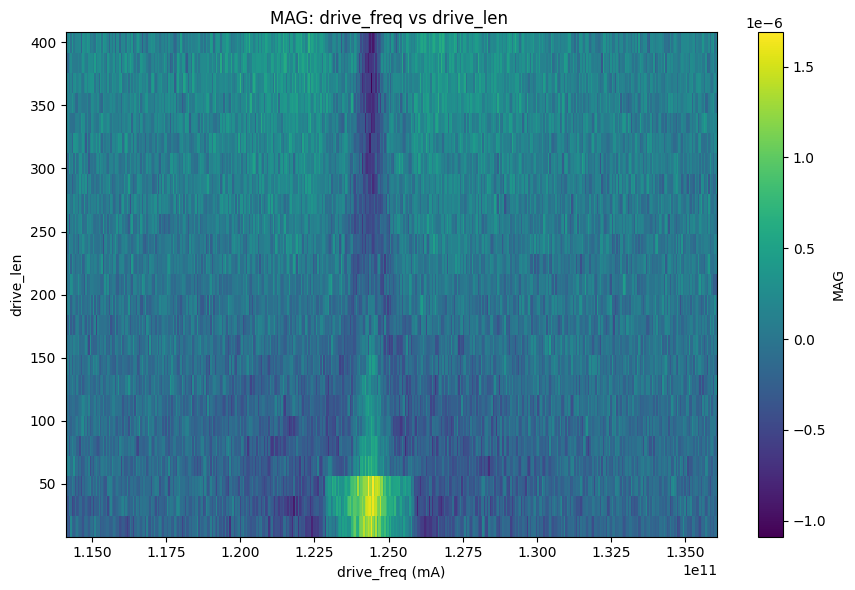

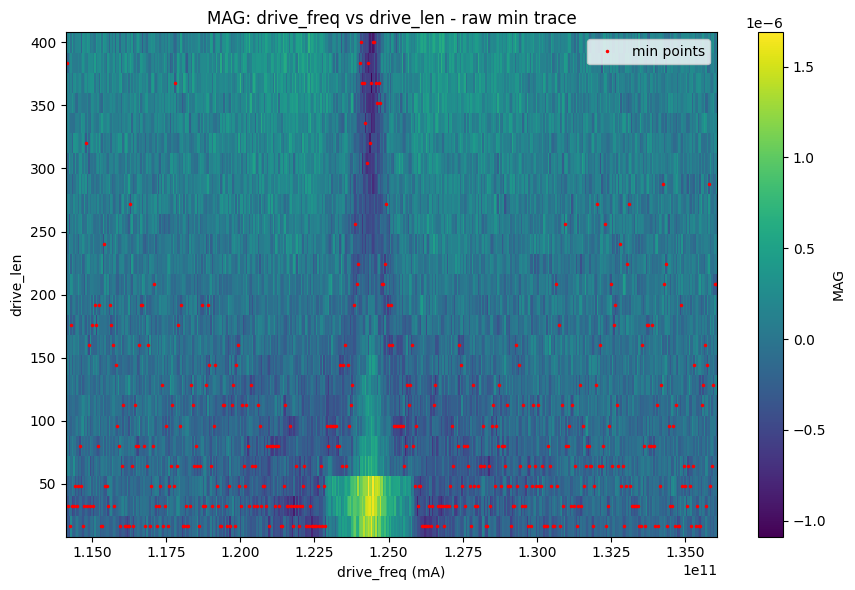

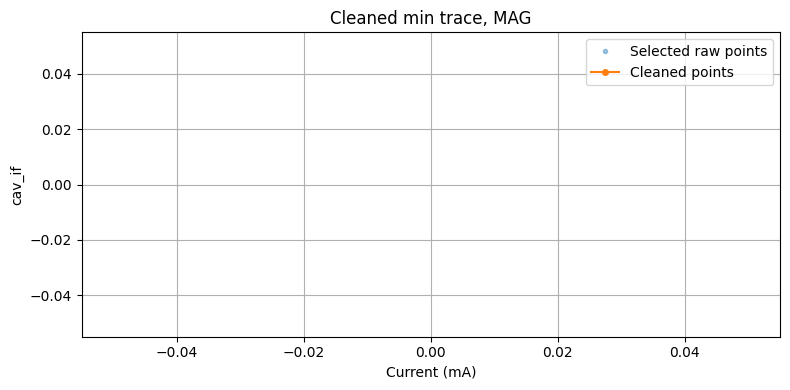

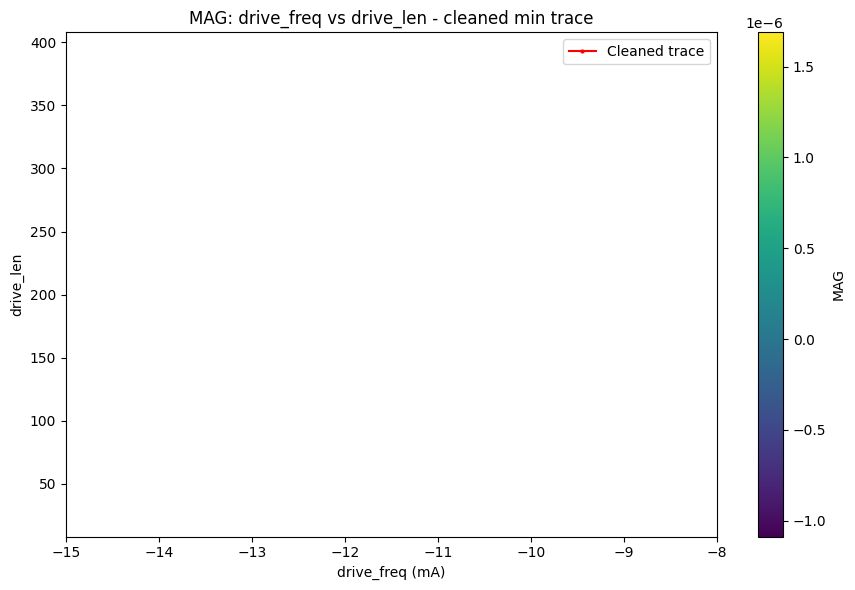


current = []

cav_if = []


In [3]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
sweep =np.linspace(start=124.15e6-10e6, stop=124.2e6+12e6, num=441)#=np.linspace(start=124.15e6-10e6, stop=124.2e6+12e6, num=221)#[0:121]
batches = [
    {
        "date": "2026-07-13",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-13",
        "time": ((14, 17), (16, 40)),
        "current": sweep#[0:104]#np.linspace(-20e-3, 20e-3, 801)[0:237],
    },
    # {
    #     "date": "2026-07-05",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "time": ((0, 0), (6, 0)),
    #     "current": np.linspace(-20e-3, 20e-3, 801)[237:237+274],
    # },
]

file_key = "cav_swap_1d_len_loop_freq_fock1"
plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "drive_freq", "drive_len"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

Keys in NPZ:
['x_values', 'current', 'current_mA', 'y_values', 'cav_if', 'sweep_axis', 'I', 'Q', 'MAG', 'x_label', 'y_label', 'y_key', 'filenames', 'file_dates', 'file_times', 'batch_dates', 'batch_start_times', 'batch_end_times', 'batch_folders', 'file_key', 'subtract_mean', 'plot_data_saved']
x shape: (120,)
y shape: (101,)
z shape: (120, 101)


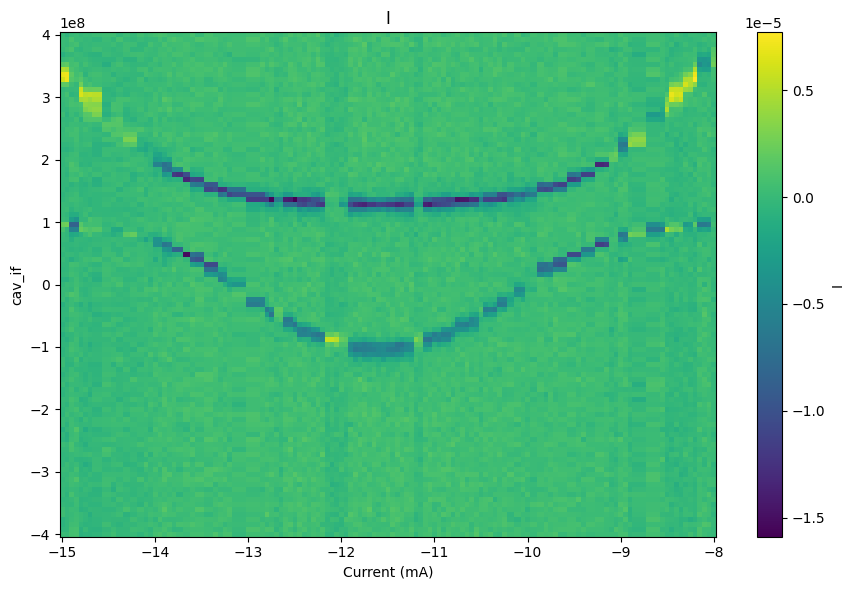

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Load NPZ
# ==========================================================
npz_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I.npz"

data = np.load(npz_path, allow_pickle=True)

print("Keys in NPZ:")
print(data.files)

# ==========================================================
# Select data to plot
# ==========================================================
plot_data = "I"      # "I", "Q", or "MAG"

x = data["current"]          # Current (A)
y = data["cav_if"]           # Frequency axis

z = data[plot_data]

# Convert to numpy array in case it was saved as a list
z = np.asarray(z)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("z shape:", z.shape)

# ==========================================================
# Plot
# ==========================================================
plt.figure(figsize=(9,6))

plt.pcolormesh(
    x * 1e3,        # convert to mA
    y,
    z.T,
    shading="auto",
    cmap="viridis"
)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(plot_data)
plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260703_1810_to_20260704_1400_I.npz


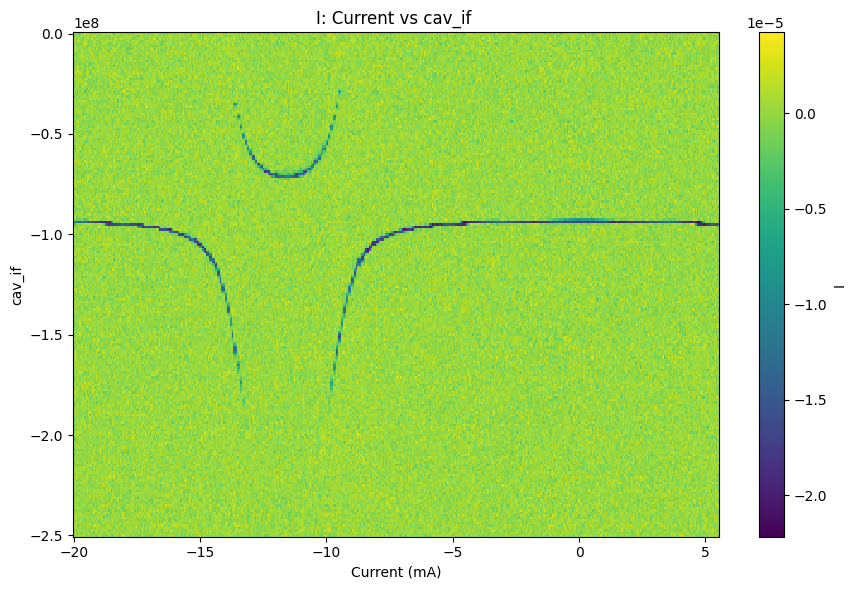

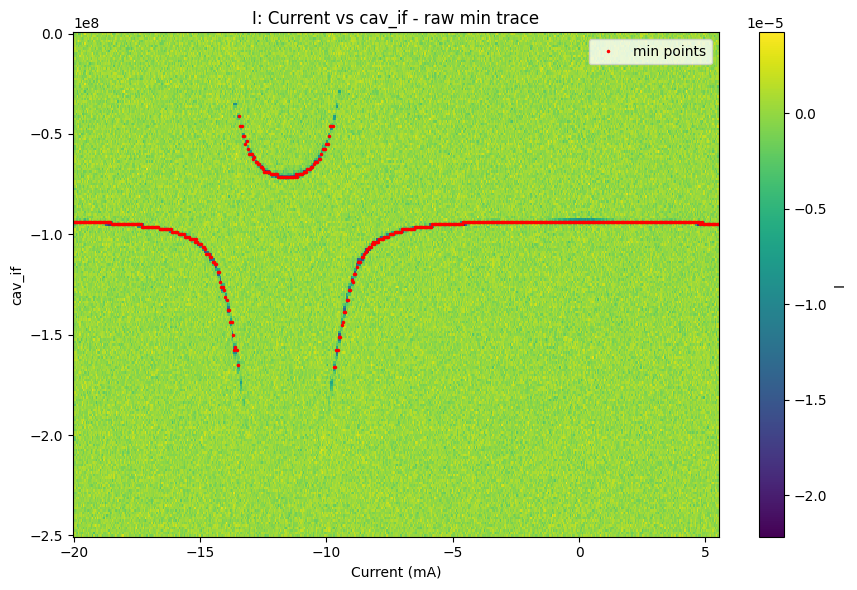

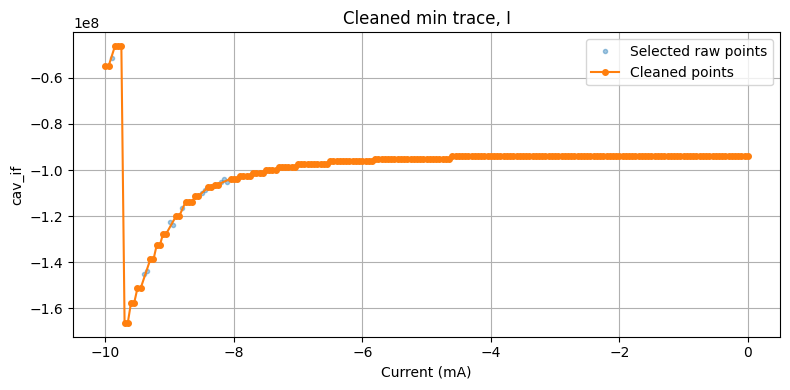

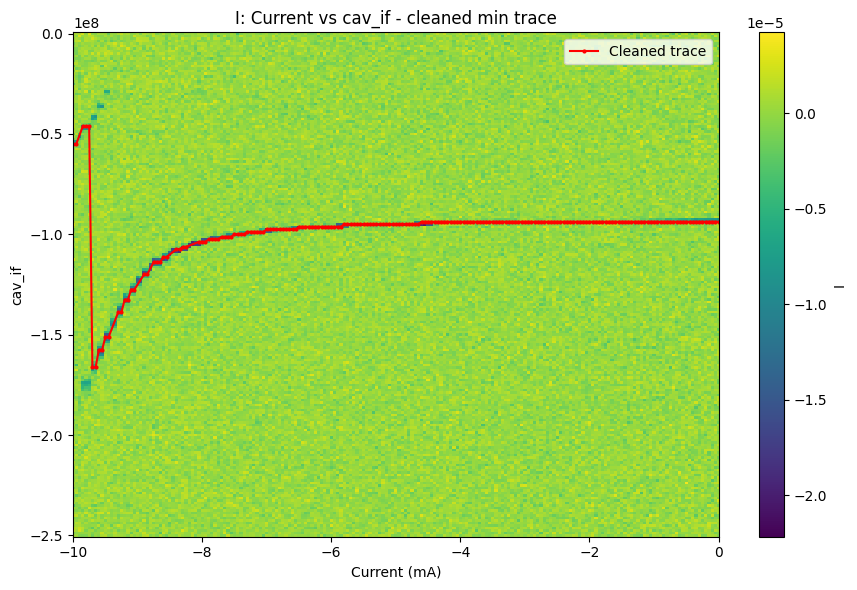


current = [-0.01, -0.00995, -0.00985, -0.0098, -0.00975, -0.0097, -0.00965, -0.0096, -0.00955, -0.0095, -0.00945, -0.0093, -0.00925, -0.0092, -0.00915, -0.0091, -0.00905, -0.0089, -0.00885, -0.00875, -0.0087, -0.00865, -0.0086, -0.00855, -0.0084, -0.00835, -0.0083, -0.00825, -0.00805, -0.008, -0.00795, -0.0079, -0.00785, -0.0078, -0.00775, -0.0077, -0.00765, -0.0076, -0.00755, -0.0075, -0.00745, -0.0074, -0.00735, -0.0073, -0.00725, -0.0072, -0.00715, -0.0071, -0.00705, -0.007, -0.00695, -0.0069, -0.00685, -0.0068, -0.00675, -0.0067, -0.00665, -0.0066, -0.00655, -0.0065, -0.00645, -0.0064, -0.00635, -0.0063, -0.00625, -0.0062, -0.00615, -0.0061, -0.00605, -0.006, -0.00595, -0.0059, -0.00585, -0.0058, -0.00575, -0.0057, -0.00565, -0.0056, -0.00555, -0.0055, -0.00545, -0.0054, -0.00535, -0.0053, -0.00525, -0.0052, -0.00515, -0.0051, -0.00505, -0.005, -0.00495, -0.0049, -0.00485, -0.0048, -0.00475, -0.0047, -0.00465, -0.0046, -0.00455, -0.0045, -0.00445, -0.0044, -0.00435, -0.0043, -0.00

In [5]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-07-03",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-03",
        "time": ((18, 10), (23, 59)),
        "current": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:248],
    },
    {
        "date": "2026-07-04",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-04",
        "time": ((0, 0), (14, 0)),
        "current": np.linspace(start=-20e-3, stop=20e-3, num=801)[248:248+263],
    },
]

file_key = "CavitySpec_versus_flux"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA =-10, 0
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

In [6]:
print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")


current = [-10, -9.95, -9.85, -9.8, -9.75, -9.7, -9.65, -9.6, -9.55, -9.5, -9.45, -9.3, -9.25, -9.2, -9.15, -9.1, -9.05, -8.9, -8.85, -8.75, -8.7, -8.65, -8.6, -8.55, -8.4, -8.35, -8.3, -8.25, -8.05, -8, -7.95, -7.9, -7.85, -7.8, -7.75, -7.7, -7.65, -7.6, -7.55, -7.5, -7.45, -7.4, -7.35, -7.3, -7.25, -7.2, -7.15, -7.1, -7.05, -7, -6.95, -6.9, -6.85, -6.8, -6.75, -6.7, -6.65, -6.6, -6.55, -6.5, -6.45, -6.4, -6.35, -6.3, -6.25, -6.2, -6.15, -6.1, -6.05, -6, -5.95, -5.9, -5.85, -5.8, -5.75, -5.7, -5.65, -5.6, -5.55, -5.5, -5.45, -5.4, -5.35, -5.3, -5.25, -5.2, -5.15, -5.1, -5.05, -5, -4.95, -4.9, -4.85, -4.8, -4.75, -4.7, -4.65, -4.6, -4.55, -4.5, -4.45, -4.4, -4.35, -4.3, -4.25, -4.2, -4.15, -4.1, -4.05, -4, -3.95, -3.9, -3.85, -3.8, -3.75, -3.7, -3.65, -3.6, -3.55, -3.5, -3.45, -3.4, -3.35, -3.3, -3.25, -3.2, -3.15, -3.1, -3.05, -3, -2.95, -2.9, -2.85, -2.8, -2.75, -2.7, -2.65, -2.6, -2.55, -2.5, -2.45, -2.4, -2.35, -2.3, -2.25, -2.2, -2.15, -2.1, -2.05, -2, -1.95, -1.9, -1.85, -1.8, -

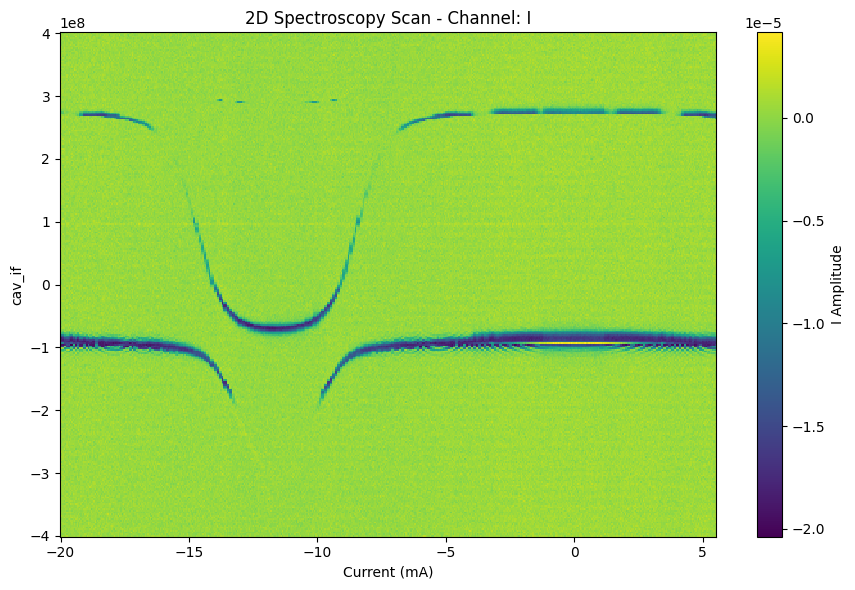

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SELECTION CONFIGURATION
# ==========================================================
# Choose your channel here: "I", "Q", "MAG", or "PHASE"
CHOSEN_CHANNEL = "I"  

# Path to your master 2D dataset
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flu_20260704_1906_to_20260705_0600_I.npz"

# ==========================================================
# LOAD AND COMPUTE
# ==========================================================
with np.load(file_path, allow_pickle=True) as data:
    current_mA = data["current_mA"]
    cav_if = data["cav_if"]
    
    I_matrix = data["I"]
    Q_matrix = data["Q"]

# Direct mapping dictionary using lazy computation
channel_map = {
    "I":     lambda: I_matrix,
    "Q":     lambda: Q_matrix,
    "MAG":   lambda: np.sqrt(I_matrix**2 + Q_matrix**2),
    "PHASE": lambda: np.arctan2(Q_matrix, I_matrix)  # Returns phase in radians (-π to π)
}

# Validate user choice safely
if CHOSEN_CHANNEL.upper() not in channel_map:
    raise ValueError(f"Invalid channel selection '{CHOSEN_CHANNEL}'. Choose from: {list(channel_map.keys())}")

# Extract selected matrix data
selected_matrix = channel_map[CHOSEN_CHANNEL.upper()]()

# Set up specific color map preferences (Phase looks much cleaner using a cyclic map like 'twilight')
cmap_choice = "twilight" if CHOSEN_CHANNEL.upper() == "PHASE" else "viridis"
cbar_label = "Phase (rad)" if CHOSEN_CHANNEL.upper() == "PHASE" else f"{CHOSEN_CHANNEL} Amplitude"

# ==========================================================
# GENERATE PLOT
# ==========================================================
plt.figure(figsize=(9, 6))

# .T transposes the data to align with current on X-axis and cav_if on Y-axis
plt.pcolormesh(current_mA, cav_if, selected_matrix.T, shading="auto", cmap=cmap_choice)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(f"2D Spectroscopy Scan - Channel: {CHOSEN_CHANNEL.upper()}")
plt.colorbar(label=cbar_label)

plt.tight_layout()
plt.show()

In [18]:
cav_if

array([-400000000, -397333334, -394666668, -392000002, -389333336,
       -386666670, -384000004, -381333338, -378666672, -376000006,
       -373333340, -370666674, -368000008, -365333342, -362666676,
       -360000010, -357333344, -354666678, -352000012, -349333346,
       -346666680, -344000014, -341333348, -338666682, -336000016,
       -333333350, -330666684, -328000018, -325333352, -322666686,
       -320000020, -317333354, -314666688, -312000022, -309333356,
       -306666690, -304000024, -301333358, -298666692, -296000026,
       -293333360, -290666694, -288000028, -285333362, -282666696,
       -280000030, -277333364, -274666698, -272000032, -269333366,
       -266666700, -264000034, -261333368, -258666702, -256000036,
       -253333370, -250666704, -248000038, -245333372, -242666706,
       -240000040, -237333374, -234666708, -232000042, -229333376,
       -226666710, -224000044, -221333378, -218666712, -216000046,
       -213333380, -210666714, -208000048, -205333382, -202666

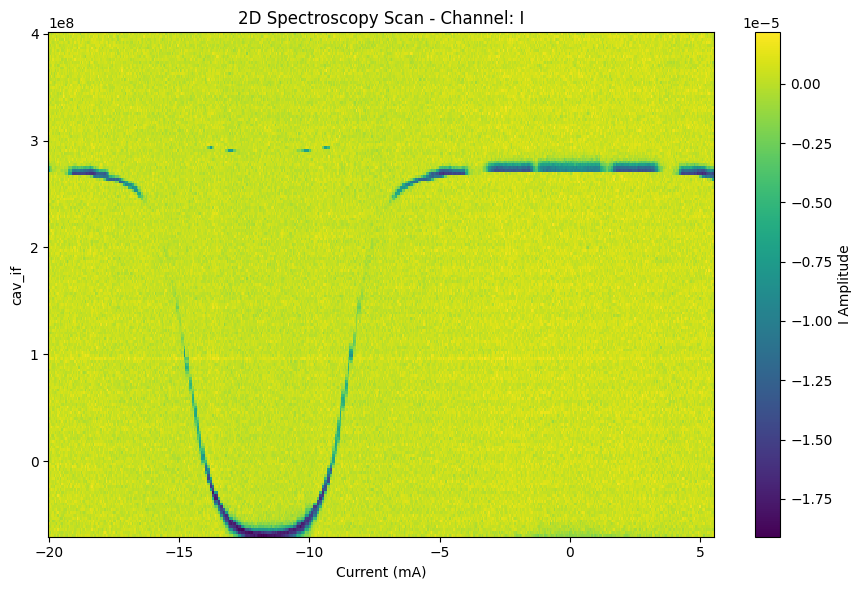

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SELECTION CONFIGURATION
# ==========================================================
# Choose your channel here: "I", "Q", "MAG", or "PHASE"
CHOSEN_CHANNEL = "I"  

# Path to your master 2D dataset
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flu_20260704_1906_to_20260705_0600_I.npz"

# ==========================================================
# LOAD AND COMPUTE
# ==========================================================
with np.load(file_path, allow_pickle=True) as data:
    current_mA = data["current_mA"]
    cav_if = data["cav_if"]
    
    I_matrix = data["I"]
    Q_matrix = data["Q"]

# Direct mapping dictionary using lazy computation
channel_map = {
    "I":     lambda: I_matrix,
    "Q":     lambda: Q_matrix,
    "MAG":   lambda: np.sqrt(I_matrix**2 + Q_matrix**2),
    "PHASE": lambda: np.arctan2(Q_matrix, I_matrix)  # Returns phase in radians (-π to π)
}

# Validate user choice safely
if CHOSEN_CHANNEL.upper() not in channel_map:
    raise ValueError(f"Invalid channel selection '{CHOSEN_CHANNEL}'. Choose from: {list(channel_map.keys())}")

# Extract selected matrix data
selected_matrix = channel_map[CHOSEN_CHANNEL.upper()]()

# --- FILTER DATA BELOW -1 cav_if ---
mask = cav_if >= -0.7e8
cav_if = cav_if[mask]
selected_matrix = selected_matrix[:, mask]  # Filters the cav_if axis (columns)
# -----------------------------------

# Set up specific color map preferences (Phase looks much cleaner using a cyclic map like 'twilight')
cmap_choice = "twilight" if CHOSEN_CHANNEL.upper() == "PHASE" else "viridis"
cbar_label = "Phase (rad)" if CHOSEN_CHANNEL.upper() == "PHASE" else f"{CHOSEN_CHANNEL} Amplitude"

# ==========================================================
# GENERATE PLOT
# ==========================================================
plt.figure(figsize=(9, 6))

# .T transposes the data to align with current on X-axis and cav_if on Y-axis
plt.pcolormesh(current_mA, cav_if, selected_matrix.T, shading="auto", cmap=cmap_choice)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(f"2D Spectroscopy Scan - Channel: {CHOSEN_CHANNEL.upper()}")
plt.colorbar(label=cbar_label)

plt.tight_layout()
plt.show()

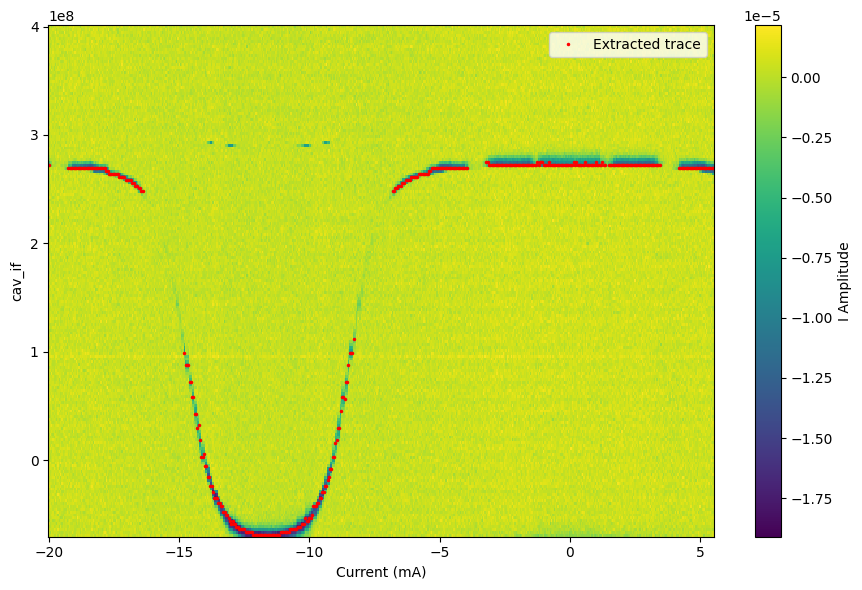

In [97]:
# ==========================================================
# EXTRACT THE TRACE (cav_if vs current)
# ==========================================================

# selected_matrix has shape (n_current, n_cav_if)
# For each current point, find the cav_if where the dip is deepest

trace_cav_if = np.zeros(len(current_mA))
trace_depth  = np.zeros(len(current_mA))

for i in range(len(current_mA)):
    col = selected_matrix[i, :]
    idx_min = np.argmin(col)          # most negative I amplitude = dip
    trace_cav_if[i] = cav_if[idx_min]
    trace_depth[i]  = col[idx_min]

# --- Optional: only keep points where the dip is "real" (exceeds a threshold) ---
# Otherwise noise floor points will get included as spurious "dips"
threshold = -0.3e-5   # tune this based on your colorbar (~ -0.3 to -0.5e-5 looks like a good cut)
valid = trace_depth < threshold

current_valid = current_mA[valid]
trace_valid   = trace_cav_if[valid]

# --- Plot to check ---
plt.figure(figsize=(9, 6))
plt.pcolormesh(current_mA, cav_if, selected_matrix.T, shading="auto", cmap="viridis")
plt.plot(current_valid, trace_valid, 'r.', markersize=3, label="Extracted trace")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.legend()
plt.colorbar(label="I Amplitude")
plt.tight_layout()
plt.show()

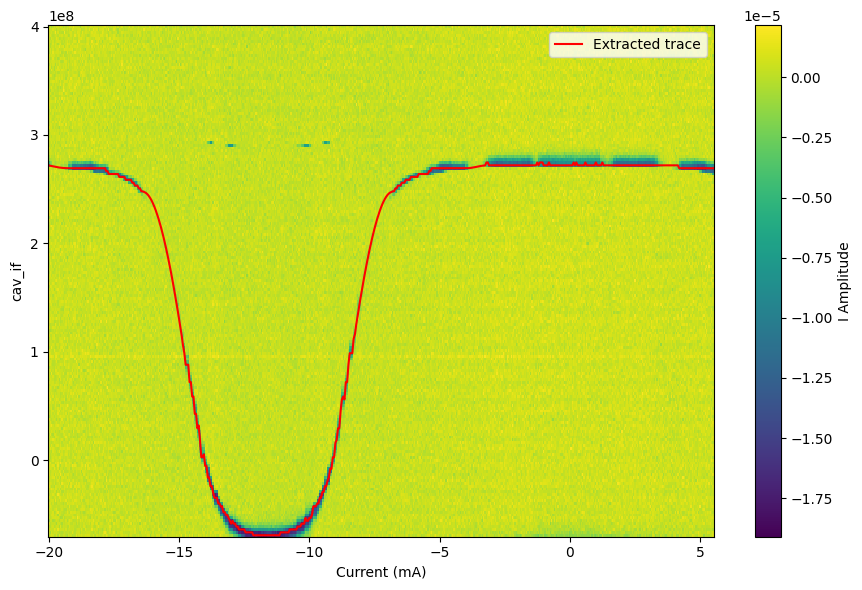

In [101]:
current_mA_trace1 = np.array([
-20.000000, -19.950000, -19.900000, -19.850000, -19.800000, -19.750000, -19.700000, -19.650000, -19.600000, -19.550000, -19.500000, -19.450000, -19.400000, -19.350000, -19.300000, -19.250000, -19.200000, -19.150000, -19.100000, -19.050000, -19.000000, -18.950000, -18.900000, -18.850000, -18.800000, -18.750000, -18.700000, -18.650000, -18.600000, -18.550000, -18.500000, -18.450000, -18.400000, -18.350000, -18.300000, -18.250000, -18.200000, -18.150000, -18.100000, -18.050000, -18.000000, -17.950000, -17.900000, -17.850000, -17.800000, -17.750000, -17.700000, -17.650000, -17.600000, -17.550000, -17.500000, -17.450000, -17.400000, -17.350000, -17.300000, -17.250000, -17.200000, -17.150000, -17.100000, -17.050000, -17.000000, -16.950000, -16.900000, -16.850000, -16.800000, -16.750000, -16.700000, -16.650000, -16.600000, -16.550000, -16.500000, -16.450000, -16.400000, -16.350000, -16.300000, -16.250000, -16.200000, -16.150000, -16.100000, -16.050000, -16.000000, -15.950000, -15.900000, -15.850000, -15.800000, -15.750000, -15.700000, -15.650000, -15.600000, -15.550000, -15.500000, -15.450000, -15.400000, -15.350000, -15.300000, -15.250000, -15.200000, -15.150000, -15.100000, -15.050000, -15.000000, -14.950000, -14.900000, -14.850000, -14.800000, -14.750000, -14.700000, -14.650000, -14.600000, -14.550000, -14.500000, -14.450000, -14.400000, -14.350000, -14.300000, -14.250000, -14.200000, -14.150000, -14.100000, -14.050000, -14.000000, -13.950000, -13.900000, -13.850000, -13.800000, -13.750000, -13.700000, -13.650000, -13.600000, -13.550000, -13.500000, -13.450000, -13.400000, -13.350000, -13.300000, -13.250000, -13.200000, -13.150000, -13.100000, -13.050000, -13.000000, -12.950000, -12.900000, -12.850000, -12.800000, -12.750000, -12.700000, -12.650000, -12.600000, -12.550000, -12.500000, -12.450000, -12.400000, -12.350000, -12.300000, -12.250000, -12.200000, -12.150000, -12.100000, -12.050000, -12.000000, -11.950000, -11.900000, -11.850000, -11.800000, -11.750000, -11.700000, -11.650000, -11.600000, -11.550000, -11.500000, -11.450000, -11.400000, -11.350000, -11.300000, -11.250000, -11.200000, -11.150000, -11.100000, -11.050000, -11.000000, -10.950000, -10.900000, -10.850000, -10.800000, -10.750000, -10.700000, -10.650000, -10.600000, -10.550000, -10.500000, -10.450000, -10.400000, -10.350000, -10.300000, -10.250000, -10.200000, -10.150000, -10.100000, -10.050000, -10.000000, -9.950000, -9.900000, -9.850000, -9.800000, -9.750000, -9.700000, -9.650000, -9.600000, -9.550000, -9.500000, -9.450000, -9.400000, -9.350000, -9.300000, -9.250000, -9.200000, -9.150000, -9.100000, -9.050000, -9.000000, -8.950000, -8.900000, -8.850000, -8.800000, -8.750000, -8.700000, -8.650000, -8.600000, -8.550000, -8.500000, -8.450000, -8.400000, -8.350000, -8.300000, -8.250000, -8.200000, -8.150000, -8.100000, -8.050000, -8.000000, -7.950000, -7.900000, -7.850000, -7.800000, -7.750000, -7.700000, -7.650000, -7.600000, -7.550000, -7.500000, -7.450000, -7.400000, -7.350000, -7.300000, -7.250000, -7.200000, -7.150000, -7.100000, -7.050000, -7.000000, -6.950000, -6.900000, -6.850000, -6.800000, -6.750000, -6.700000, -6.650000, -6.600000, -6.550000, -6.500000, -6.450000, -6.400000, -6.350000, -6.300000, -6.250000, -6.200000, -6.150000, -6.100000, -6.050000, -6.000000, -5.950000, -5.900000, -5.850000, -5.800000, -5.750000, -5.700000, -5.650000, -5.600000, -5.550000, -5.500000, -5.450000, -5.400000, -5.350000, -5.300000, -5.250000, -5.200000, -5.150000, -5.100000, -5.050000, -5.000000, -4.950000, -4.900000, -4.850000, -4.800000, -4.750000, -4.700000, -4.650000, -4.600000, -4.550000, -4.500000, -4.450000, -4.400000, -4.350000, -4.300000, -4.250000, -4.200000, -4.150000, -4.100000, -4.050000, -4.000000, -3.950000, -3.900000, -3.850000, -3.800000, -3.750000, -3.700000, -3.650000, -3.600000, -3.550000, -3.500000, -3.450000, -3.400000, -3.350000, -3.300000, -3.250000, -3.200000, -3.150000, -3.100000, -3.050000, -3.000000, -2.950000, -2.900000, -2.850000, -2.800000, -2.750000, -2.700000, -2.650000, -2.600000, -2.550000, -2.500000, -2.450000, -2.400000, -2.350000, -2.300000, -2.250000, -2.200000, -2.150000, -2.100000, -2.050000, -2.000000, -1.950000, -1.900000, -1.850000, -1.800000, -1.750000, -1.700000, -1.650000, -1.600000, -1.550000, -1.500000, -1.450000, -1.400000, -1.350000, -1.300000, -1.250000, -1.200000, -1.150000, -1.100000, -1.050000, -1.000000, -0.950000, -0.900000, -0.850000, -0.800000, -0.750000, -0.700000, -0.650000, -0.600000, -0.550000, -0.500000, -0.450000, -0.400000, -0.350000, -0.300000, -0.250000, -0.200000, -0.150000, -0.100000, -0.050000, 0.000000, 0.050000, 0.100000, 0.150000, 0.200000, 0.250000, 0.300000, 0.350000, 0.400000, 0.450000, 0.500000, 0.550000, 0.600000, 0.650000, 0.700000, 0.750000, 0.800000, 0.850000, 0.900000, 0.950000, 1.000000, 1.050000, 1.100000, 1.150000, 1.200000, 1.250000, 1.300000, 1.350000, 1.400000, 1.450000, 1.500000, 1.550000, 1.600000, 1.650000, 1.700000, 1.750000, 1.800000, 1.850000, 1.900000, 1.950000, 2.000000, 2.050000, 2.100000, 2.150000, 2.200000, 2.250000, 2.300000, 2.350000, 2.400000, 2.450000, 2.500000, 2.550000, 2.600000, 2.650000, 2.700000, 2.750000, 2.800000, 2.850000, 2.900000, 2.950000, 3.000000, 3.050000, 3.100000, 3.150000, 3.200000, 3.250000, 3.300000, 3.350000, 3.400000, 3.450000, 3.500000, 3.550000, 3.600000, 3.650000, 3.700000, 3.750000, 3.800000, 3.850000, 3.900000, 3.950000, 4.000000, 4.050000, 4.100000, 4.150000, 4.200000, 4.250000, 4.300000, 4.350000, 4.400000, 4.450000, 4.500000, 4.550000, 4.600000, 4.650000, 4.700000, 4.750000, 4.800000, 4.850000, 4.900000, 4.950000, 5.000000, 5.050000, 5.100000, 5.150000, 5.200000, 5.250000, 5.300000, 5.350000, 5.400000, 5.450000, 5.500000
])

cav_if_trace1 = np.array([
2.719998e+08, 2.716159e+08, 2.713742e+08, 2.710828e+08, 2.708131e+08, 2.705653e+08, 2.703397e+08, 2.701366e+08, 2.699564e+08, 2.697992e+08, 2.696655e+08, 2.695555e+08, 2.694695e+08, 2.694077e+08, 2.693681e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.666665e+08, 2.666665e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.586665e+08, 2.586665e+08, 2.586665e+08, 2.586665e+08, 2.586665e+08, 2.559998e+08, 2.559998e+08, 2.533332e+08, 2.533332e+08, 2.533332e+08, 2.506665e+08, 2.506665e+08, 2.479998e+08, 2.479998e+08, 2.474956e+08, 2.469246e+08, 2.460382e+08, 2.448066e+08, 2.432368e+08, 2.413357e+08, 2.391103e+08, 2.365677e+08, 2.337147e+08, 2.305585e+08, 2.271059e+08, 2.233640e+08, 2.193397e+08, 2.150401e+08, 2.104721e+08, 2.056427e+08, 2.005588e+08, 1.952276e+08, 1.896560e+08, 1.838509e+08, 1.778193e+08, 1.715683e+08, 1.651047e+08, 1.584357e+08, 1.515682e+08, 1.445091e+08, 1.372655e+08, 1.298444e+08, 1.222526e+08, 1.144973e+08, 1.055610e+08, 9.866654e+07, 8.799988e+07, 8.799988e+07, 8.799988e+07, 7.199988e+07, 7.199988e+07, 5.866655e+07, 5.866655e+07, 4.266656e+07, 4.266656e+07, 2.933323e+07, 3.199989e+07, 1.866656e+07, 2.666566e+06, 2.666566e+06, 5.333232e+06, -5.333432e+06, -5.333432e+06, -1.600010e+07, -1.600010e+07, -2.400009e+07, -2.400009e+07, -2.933343e+07, -3.466676e+07, -3.466676e+07, -3.466676e+07, -4.000009e+07, -4.000009e+07, -4.266676e+07, -4.266676e+07, -4.800009e+07, -4.800009e+07, -5.066675e+07, -5.066675e+07, -5.333342e+07, -5.600009e+07, -5.866675e+07, -5.600009e+07, -5.866675e+07, -5.866675e+07, -6.133342e+07, -6.133342e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.933342e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.666675e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.400008e+07, -6.133342e+07, -6.133342e+07, -6.133342e+07, -5.866675e+07, -5.866675e+07, -5.866675e+07, -5.333342e+07, -5.600009e+07, -5.600009e+07, -5.333342e+07, -5.333342e+07, -5.066675e+07, -4.266676e+07, -4.266676e+07, -4.266676e+07, -4.000009e+07, -4.000009e+07, -3.466676e+07, -3.466676e+07, -2.933343e+07, -2.933343e+07, -2.400009e+07, -2.400009e+07, -1.866676e+07, -1.600010e+07, -8.000098e+06, -8.000098e+06, 2.666566e+06, 2.666566e+06, 1.599990e+07, 1.866656e+07, 2.933323e+07, 2.933323e+07, 4.533322e+07, 5.599989e+07, 5.866655e+07, 5.599989e+07, 7.199988e+07, 7.199988e+07, 8.799988e+07, 9.866654e+07, 9.866654e+07, 9.866654e+07, 1.119999e+08, 1.161477e+08, 1.250221e+08, 1.326933e+08, 1.401874e+08, 1.474967e+08, 1.546134e+08, 1.615299e+08, 1.682384e+08, 1.747313e+08, 1.810008e+08, 1.870392e+08, 1.928389e+08, 1.983920e+08, 2.036910e+08, 2.087281e+08, 2.134955e+08, 2.179857e+08, 2.221908e+08, 2.261032e+08, 2.297151e+08, 2.330189e+08, 2.360068e+08, 2.386712e+08, 2.410043e+08, 2.429984e+08, 2.446459e+08, 2.459389e+08, 2.468699e+08, 2.474698e+08, 2.479998e+08, 2.479998e+08, 2.506665e+08, 2.506665e+08, 2.533332e+08, 2.533332e+08, 2.533332e+08, 2.559998e+08, 2.559998e+08, 2.559998e+08, 2.586665e+08, 2.586665e+08, 2.586665e+08, 2.586665e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.613332e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.639998e+08, 2.666665e+08, 2.666665e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.694213e+08, 2.695149e+08, 2.696532e+08, 2.698341e+08, 2.700482e+08, 2.702861e+08, 2.705381e+08, 2.707949e+08, 2.710469e+08, 2.712848e+08, 2.714989e+08, 2.716798e+08, 2.718181e+08, 2.719117e+08, 2.746665e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.746665e+08, 2.746665e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.746665e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.719998e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08, 2.693332e+08
])

plt.figure(figsize=(9, 6))
plt.pcolormesh(current_mA, cav_if, selected_matrix.T, shading="auto", cmap="viridis")
plt.plot(current_mA_trace1, cav_if_trace1, 'r-', linewidth=1.5, label="Extracted trace")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.legend()
plt.colorbar(label="I Amplitude")
plt.tight_layout()
plt.show()

Keys in NPZ:
['x_values', 'current', 'current_mA', 'y_values', 'cav_if', 'sweep_axis', 'I', 'Q', 'MAG', 'x_label', 'y_label', 'y_key', 'filenames', 'file_dates', 'file_times', 'batch_dates', 'batch_start_times', 'batch_end_times', 'batch_folders', 'file_key', 'subtract_mean', 'plot_data_saved']
New x shape: (88,), New z shape: (88, 64)


C:\Users\qcrew\AppData\Local\Temp\ipykernel_31760\3282982753.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


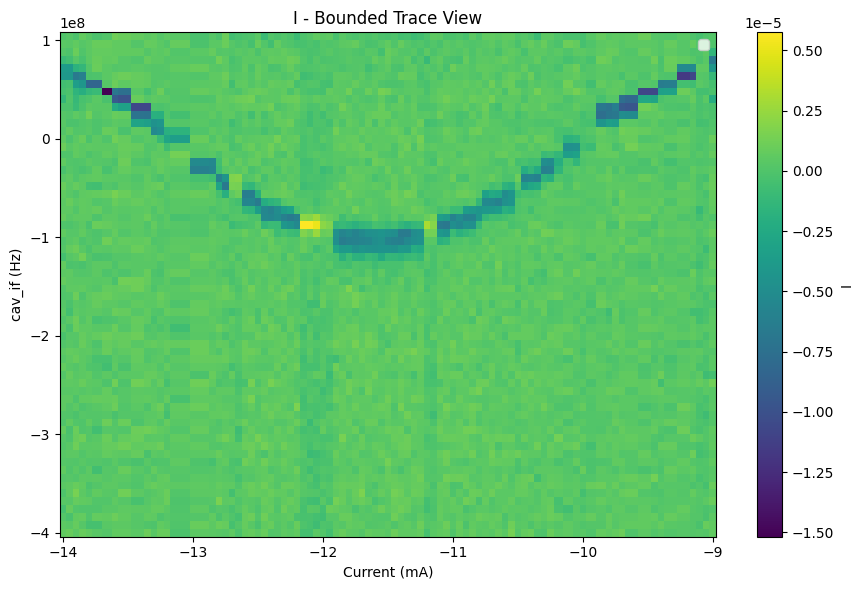

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Load NPZ
# ==========================================================
npz_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I.npz"

data = np.load(npz_path, allow_pickle=True)

print("Keys in NPZ:")
print(data.files)

# ==========================================================
# Select data to plot
# ==========================================================
plot_data = "I"      # "I", "Q", or "MAG"

# 1. Convert everything to numpy arrays upfront
x = np.asarray(data["current"])  
y = np.asarray(data["cav_if"])
z = np.asarray(data[plot_data])  

# 2. Filter y (columns of z)
mask_y = y <= 1.1e8
y = y[mask_y]
z = z[:, mask_y]

# 3. Scale the bounds to Amperes to match the data scale
mask_x = (x >= -14e-3) & (x <= -9e-3)  # -14 mA to -9 mA in Amperes
x = x[mask_x]
z = z[mask_x, :]

print(f"New x shape: {x.shape}, New z shape: {z.shape}")

# ==========================================================
# Plot
# ==========================================================
plt.figure(figsize=(9,6))

# Plot the 2D matrix background slice
plt.pcolormesh(
    x * 1e3,        # convert x axis to mA for the plot layout
    y,
    z.T,
    shading="auto",
    cmap="viridis"
)


plt.xlabel("Current (mA)")
plt.ylabel("cav_if (Hz)")
plt.title(f"{plot_data} - Bounded Trace View")
plt.colorbar(label=plot_data)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Empty columns needing interpolation: 29 out of 88
Detected 2 jump location(s) at current(s): [-13.35 -13.15]


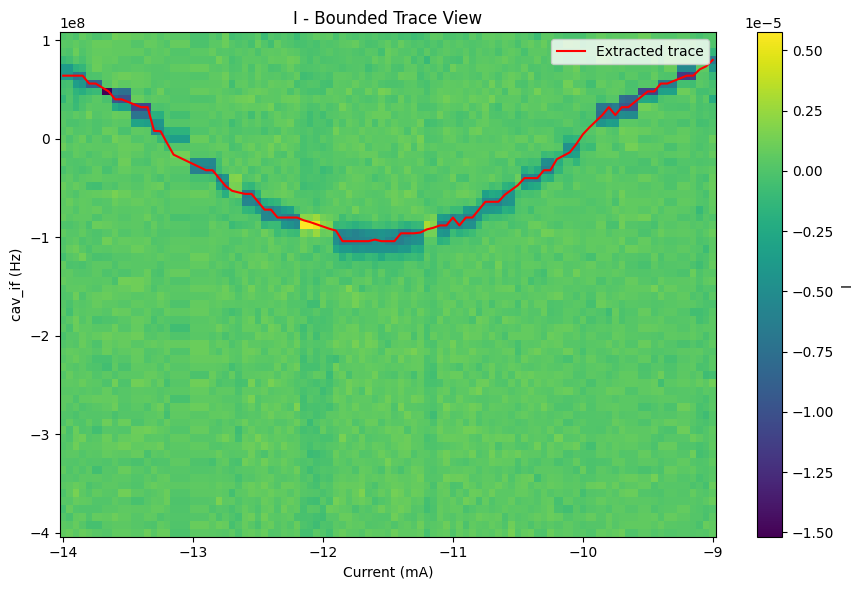

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import PchipInterpolator

# ==========================================================
# Load NPZ (same as your script)
# ==========================================================
npz_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I.npz"
data = np.load(npz_path, allow_pickle=True)

plot_data = "I"
x = np.asarray(data["current"])
y = np.asarray(data["cav_if"])
z = np.asarray(data[plot_data])

mask_y = y <= 1.1e8
y = y[mask_y]
z = z[:, mask_y]

mask_x = (x >= -14e-3) & (x <= -9e-3)
x = x[mask_x]
z = z[mask_x, :]

current_mA = x * 1e3   # keep everything downstream in mA to match the plot

# ==========================================================
# TRACE EXTRACTION (same method as before)
# ==========================================================
threshold = -0.5e-5   # tune based on your colorbar — your dip looks like it bottoms near -1 to -1.5e-5
n_curr = len(current_mA)
trace_cav_if = np.full(n_curr, np.nan)

seed_idx = np.argmin(np.min(z, axis=1))
trace_cav_if[seed_idx] = y[np.argmin(z[seed_idx, :])]

def track_direction(indices):
    prev = trace_cav_if[seed_idx]
    for i in indices:
        col = z[i, :]
        below = np.where(col < threshold)[0]
        if len(below) == 0:
            continue
        best = below[np.argmin(np.abs(y[below] - prev))]
        trace_cav_if[i] = y[best]
        prev = y[best]

track_direction(range(seed_idx - 1, -1, -1))
track_direction(range(seed_idx + 1, n_curr))

# Fill any empty columns
valid = ~np.isnan(trace_cav_if)
print(f"Empty columns needing interpolation: {(~valid).sum()} out of {n_curr}")
trace_filled = trace_cav_if.copy()
trace_filled[~valid] = np.interp(current_mA[~valid], current_mA[valid], trace_cav_if[valid])

# De-kink any big jumps
step_diff = np.abs(np.diff(trace_filled))
typical_step = np.median(step_diff)
jump_threshold = 8 * typical_step
jump_indices = np.where(step_diff > jump_threshold)[0]
print(f"Detected {len(jump_indices)} jump location(s) at current(s): {current_mA[jump_indices]}")

trace_desmoothed = trace_filled.copy()
half_window = 6
for j in jump_indices:
    lo = max(0, j - half_window)
    hi = min(n_curr, j + half_window + 1)
    trace_desmoothed[lo:hi] = np.nan

valid2 = ~np.isnan(trace_desmoothed)
pchip = PchipInterpolator(current_mA[valid2], trace_desmoothed[valid2])
trace_kink_fixed = trace_desmoothed.copy()
trace_kink_fixed[~valid2] = pchip(current_mA[~valid2])

trace_smooth = uniform_filter1d(trace_kink_fixed, size=5)

# Refine onto local argmin where real signal exists
refine_window = 1.5e7
trace_refined = trace_smooth.copy()
for i in range(n_curr):
    center = trace_refined[i]
    win_mask = np.abs(y - center) < refine_window
    if not np.any(win_mask):
        continue
    local_idx = np.where(win_mask)[0]
    best_local = local_idx[np.argmin(z[i, local_idx])]
    if z[i, best_local] < threshold:
        trace_refined[i] = y[best_local]

# ==========================================================
# Plot
# ==========================================================
plt.figure(figsize=(9, 6))
plt.pcolormesh(current_mA, y, z.T, shading="auto", cmap="viridis")
plt.plot(current_mA, trace_refined, 'r-', linewidth=1.5, label="Extracted trace")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if (Hz)")
plt.title(f"{plot_data} - Bounded Trace View")
plt.legend(loc='upper right')
plt.colorbar(label=plot_data)
plt.tight_layout()
plt.show()

np.savez("extracted_trace_threetone.npz", current_mA=current_mA, cav_if_trace=trace_refined)

In [104]:
np.set_printoptions(threshold=np.inf, linewidth=120)

print("current_mA_trace = np.array([")
print(", ".join(f"{v:.6f}" for v in current_mA))
print("])")

print("\ncav_if_trace = np.array([")
print(", ".join(f"{v:.6e}" for v in trace_refined))
print("])")

current_mA_trace = np.array([
-14.000000, -13.950000, -13.900000, -13.850000, -13.800000, -13.750000, -13.650000, -13.600000, -13.550000, -13.400000, -13.350000, -13.300000, -13.250000, -13.200000, -13.150000, -12.900000, -12.850000, -12.800000, -12.750000, -12.700000, -12.650000, -12.600000, -12.550000, -12.500000, -12.450000, -12.400000, -12.350000, -12.300000, -12.250000, -12.200000, -12.150000, -12.100000, -12.050000, -12.000000, -11.950000, -11.900000, -11.850000, -11.800000, -11.750000, -11.700000, -11.650000, -11.600000, -11.550000, -11.500000, -11.450000, -11.400000, -11.350000, -11.300000, -11.250000, -11.200000, -11.150000, -11.100000, -11.050000, -11.000000, -10.950000, -10.900000, -10.850000, -10.800000, -10.750000, -10.700000, -10.650000, -10.600000, -10.550000, -10.500000, -10.450000, -10.400000, -10.350000, -10.300000, -10.250000, -10.200000, -10.100000, -10.050000, -10.000000, -9.950000, -9.850000, -9.800000, -9.750000, -9.700000, -9.650000, -9.500000, -9.450000, -9.400

In [109]:
current_mA_trace2 = np.array([
-14.000000, -13.950000, -13.900000, -13.850000, -13.800000, -13.750000, -13.650000, -13.600000, -13.550000, -13.400000, -13.350000, -13.300000, -13.250000, -13.200000, -13.150000, -12.900000, -12.850000, -12.800000, -12.750000, -12.700000, -12.650000, -12.600000, -12.550000, -12.500000, -12.450000, -12.400000, -12.350000, -12.300000, -12.250000, -12.200000, -12.150000, -12.100000, -12.050000, -12.000000, -11.950000, -11.900000, -11.850000, -11.800000, -11.750000, -11.700000, -11.650000, -11.600000, -11.550000, -11.500000, -11.450000, -11.400000, -11.350000, -11.300000, -11.250000, -11.200000, -11.150000, -11.100000, -11.050000, -11.000000, -10.950000, -10.900000, -10.850000, -10.800000, -10.750000, -10.700000, -10.650000, -10.600000, -10.550000, -10.500000, -10.450000, -10.400000, -10.350000, -10.300000, -10.250000, -10.200000, -10.100000, -10.050000, -10.000000, -9.950000, -9.850000, -9.800000, -9.750000, -9.700000, -9.650000, -9.500000, -9.450000, -9.400000, -9.350000, -9.200000, -9.150000, -9.100000, -9.050000, -9.000000
])

cav_if_trace2 = np.array([
6.400000e+07, 6.400000e+07, 6.400000e+07, 6.400000e+07, 5.600000e+07, 5.600000e+07, 4.800000e+07, 4.000000e+07, 4.000000e+07, 3.200000e+07, 3.200000e+07, 8.000000e+06, 7.552000e+06, -4.516352e+06, -1.616998e+07, -3.200000e+07, -3.200000e+07, -4.000000e+07, -4.800000e+07, -5.285120e+07, -5.449779e+07, -5.600000e+07, -5.600000e+07, -6.400000e+07, -7.200000e+07, -7.200000e+07, -8.000000e+07, -8.000000e+07, -8.000000e+07, -8.000000e+07, -8.274286e+07, -8.457143e+07, -8.685714e+07, -8.914286e+07, -9.142857e+07, -9.325714e+07, -1.040000e+08, -1.040000e+08, -1.040000e+08, -1.040000e+08, -1.040000e+08, -1.024000e+08, -1.040000e+08, -1.040000e+08, -1.040000e+08, -9.600000e+07, -9.600000e+07, -9.600000e+07, -9.520000e+07, -9.200000e+07, -9.040000e+07, -8.800000e+07, -8.800000e+07, -8.000000e+07, -8.800000e+07, -8.000000e+07, -8.000000e+07, -7.200000e+07, -6.400000e+07, -6.400000e+07, -6.400000e+07, -5.680000e+07, -5.200000e+07, -4.720000e+07, -4.000000e+07, -4.000000e+07, -4.000000e+07, -3.200000e+07, -3.200000e+07, -2.080000e+07, -1.380000e+07, -5.400000e+06, 4.400000e+06, 1.140000e+07, 2.400000e+07, 3.200000e+07, 2.400000e+07, 3.200000e+07, 3.200000e+07, 4.800000e+07, 4.800000e+07, 5.600000e+07, 5.600000e+07, 6.400000e+07, 6.400000e+07, 7.040000e+07, 7.360000e+07, 8.000000e+07
]) - 200e+06

Replaced 101 of 511 points in the current range [-14.000, -9.000] mA


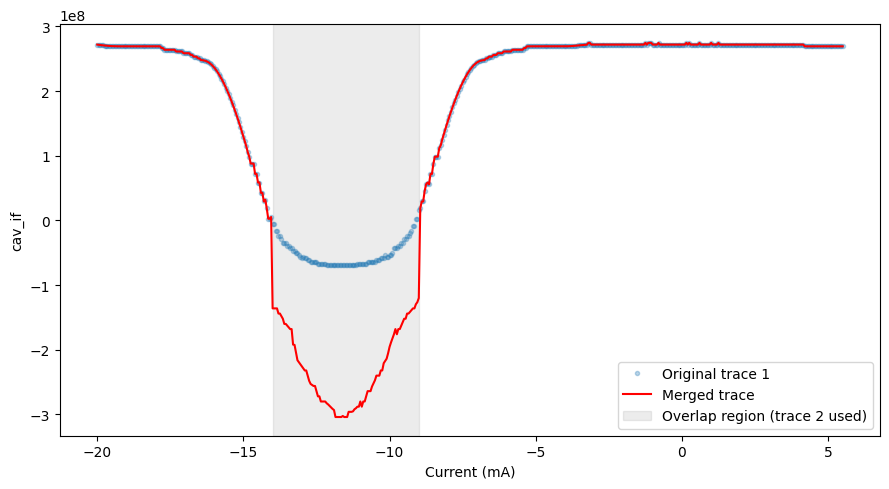

In [110]:
import numpy as np

# --- Rename for clarity: trace1 = twotone (wider scan), trace2 = threetone (narrower scan) ---
# current_mA_trace1, cav_if_trace1   -> from the first script
# current_mA_trace2, cav_if_trace2   -> from the threetone script (paste your printed arrays here)

merged_current = current_mA_trace1.copy()
merged_cav_if  = cav_if_trace1.copy()

# Which trace1 points fall inside trace2's current range?
overlap_mask = (current_mA_trace1 >= current_mA_trace2.min()) & \
               (current_mA_trace1 <= current_mA_trace2.max())

# Interpolate trace2 onto those overlapping current points and overwrite
merged_cav_if[overlap_mask] = np.interp(
    current_mA_trace1[overlap_mask],
    current_mA_trace2,
    cav_if_trace2
)

print(f"Replaced {overlap_mask.sum()} of {len(merged_current)} points "
      f"in the current range [{current_mA_trace2.min():.3f}, {current_mA_trace2.max():.3f}] mA")

# --- Sanity check plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.plot(current_mA_trace1, cav_if_trace1, 'o', markersize=3, alpha=0.3, label="Original trace 1")
plt.plot(merged_current, merged_cav_if, 'r-', linewidth=1.5, label="Merged trace")
plt.axvspan(current_mA_trace2.min(), current_mA_trace2.max(), color='gray', alpha=0.15,
            label="Overlap region (trace 2 used)")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.legend()
plt.tight_layout()
plt.show()

np.savez("merged_trace.npz", current_mA=merged_current, cav_if_trace=merged_cav_if)

merged_current_mA = np.array([
-20.000000, -19.950000, -19.900000, -19.850000, -19.800000, -19.750000, -19.700000, -19.650000, -19.600000, -19.550000, -19.500000, -19.450000, -19.400000, -19.350000, -19.300000, -19.250000, -19.200000, -19.150000, -19.100000, -19.050000, -19.000000, -18.950000, -18.900000, -18.850000, -18.800000, -18.750000, -18.700000, -18.650000, -18.600000, -18.550000, -18.500000, -18.450000, -18.400000, -18.350000, -18.300000, -18.250000, -18.200000, -18.150000, -18.100000, -18.050000, -18.000000, -17.950000, -17.900000, -17.850000, -17.800000, -17.750000, -17.700000, -17.650000, -17.600000, -17.550000, -17.500000, -17.450000, -17.400000, -17.350000, -17.300000, -17.250000, -17.200000, -17.150000, -17.100000, -17.050000, -17.000000, -16.950000, -16.900000, -16.850000, -16.800000, -16.750000, -16.700000, -16.650000, -16.600000, -16.550000, -16.500000, -16.450000, -16.400000, -16.350000, -16.300000, -16.250000, -16.200000, -16.150000, -16.100000, -16.050000, -16.00000

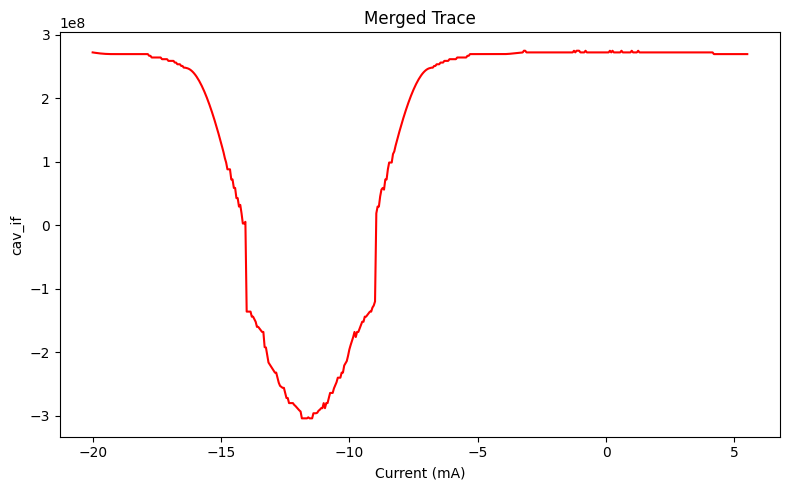

In [111]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(threshold=np.inf, linewidth=120)

print("merged_current_mA = np.array([")
print(", ".join(f"{v:.6f}" for v in merged_current))
print("])")

print("\nmerged_cav_if_trace = np.array([")
print(", ".join(f"{v:.6e}" for v in merged_cav_if))
print("])")

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(merged_current, merged_cav_if, '-', linewidth=1.5, color='red')
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title("Merged Trace")
plt.tight_layout()
plt.show()